<a href="https://colab.research.google.com/github/Petroselinum/NPL/blob/main/NPL_analiza_rekomendacji_PB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Naszym głównym narzędziem analitycznym jest biblioteka spaCy: https://spacy.io/
SpaCy to biblioteka open-source do zaawansowanego przetwarzania języka naturalnego

W poniższej komórce z kodem pobieramy model dla języka polskiego w bibliotece spaCy — nie słownik w tradycyjnym sensie, ale wytrenowaną sieć neuronową.

Co oznacza nazwa:
- pl — język polski
- core — model ogólnego przeznaczenia
- news — wytrenowany głównie na tekstach prasowych
- lg — rozmiar large

In [ ]:
!python -m spacy download pl_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 573.7/573.7 MB 949.9 kB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pl_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Importujemy potrzebne do analizy narzędzia:
- Biblioteka spacy - opisana we wstępie
- Pandas - podstawowe narzędzie do wczytania i zarządzania danymi
- re - wyrażenia regularne tj. przetwarzanie tekstu jego filtowanie/modyfkiowanie w oparciu o zdefiniowane w kodzie wzorce
- numpy - biblioteka do analiz numerycznych/algebra liniowa
- sklearn - obecnie scikit-learn to główna bibilioteka python do uczenia maszynowego
- matplotlib - wizualizacja danych
- seaborn - wizualizacja danych
- scipy - obliczenia naukowe i techniczne
- plotly - wizualizacje interaktywne
- torch - biblioteka pytorch (uczenie głębokie)
- transformers - przetwarzanie tekstu

In [ ]:
%pip install transformers torch

In [ ]:
import spacy
import pandas as pd
import re
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from transformers import AutoTokenizer, AutoModel
import torch

Załadowanie rekomendacji do pamięci operacyjnej:

In [ ]:
df = pd.read_excel('https://raw.githubusercontent.com/Petroselinum/NPL/main/Rekomendacje.xlsx').dropna()
df.head()

,Nr rekomendacji,Rekomendacja
0,1.0,W poszukiwaniu ogólnych/filozoficznych podstaw...
1,2.0,"Ekosystemy leśne prezentują wartości, spośród ..."
2,3.0,Mamy do czynienia z pluralizmem antropologiczn...
3,4.0,Zarządzanie lasami powinno uwzględniać mnogość...
4,5.0,Ekosystem leśny/las nie jest jedynie przedmiot...


Wpierw musimy dokonać normalizacji tekstu: oczyścić każdą rekomendację ze zbędnych dla modelu znaków wprowadzających niepotrzebny szum w danych. Do tego celu posłuży poniższa funkcja:

In [ ]:
#Oczyszczamy tekst

def normalize_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"\d+", "", text)            # usuwa cyfry i liczby
    text = re.sub(r"[^\w\s]", " ", text,        # usuwa wszystko co NIE jest literą ani spacją
                  flags=re.UNICODE)            #flaga UNICODE chroni polskie znaki
    text = re.sub(r"_", "", text)              # usuwa podkreślenia _ (bo \w wyżej je przepuszcza)
    text = re.sub(r"\s+", " ", text).strip()   # zamienia wielokrotne spacje na jedną, strip() usuwa spacje z brzegów

    return text

Aplikujemy naszą funkcję na każdej rekomendacji.
Rekomendacja_norm obrazuje znormalizowany tekst:

In [ ]:
df['Rekomendacja_norm'] = df['Rekomendacja'].apply(normalize_text)
df.head()

,Nr rekomendacji,Rekomendacja,Rekomendacja_norm
0,1.0,W poszukiwaniu ogólnych/filozoficznych podstaw...,w poszukiwaniu ogólnych filozoficznych podstaw...
1,2.0,"Ekosystemy leśne prezentują wartości, spośród ...",ekosystemy leśne prezentują wartości spośród k...
2,3.0,Mamy do czynienia z pluralizmem antropologiczn...,mamy do czynienia z pluralizmem antropologiczn...
3,4.0,Zarządzanie lasami powinno uwzględniać mnogość...,zarządzanie lasami powinno uwzględniać mnogość...
4,5.0,Ekosystem leśny/las nie jest jedynie przedmiot...,ekosystem leśny las nie jest jedynie przedmiot...


Wczytujemy do pamięci model języka polskiego, przechowywany po zmienną nlp:

In [ ]:
nlp = spacy.load("pl_core_news_lg")

Definiujemy zbór tzw. stop words - słowa które są bardzo częste w tekście i gramatycznie "puste" tj. nie niosą istotnej treści i znaczenia

In [ ]:
CUSTOM_STOPWORDS = {
    # Jednoliterowe i dwuliterowe (przepuszczone przez \w)
    "np", "tj", "tzw", "itp", "itd", "ww", "vs",

    # Przyimki i spójniki
    "oraz", "czyli", "bądź", "albo", "wobec", "według", "celem",
    "poprzez", "względem", "wśród", "spośród", "zarówno", "także",
    "również", "zwłaszcza", "natomiast", "jednak", "ponadto",
    "między", "poza", "chodzi",

    # Zaimki
    "jego", "jej", "ich", "tych", "tego", "tym", "które",
    "których", "innych", "różnych", "wszystkich", "nowych", "nowe",

    # Czasowniki ogólne i modalne
    "należy", "być", "jest", "są", "będzie", "powinny", "powinna",
    "powinno", "powinien", "może", "wymaga", "istnieje",

    # Rzeczowniki bez wartości semantycznej
    "rekomendacja", "program", "zakres", "zakresu", "poziom",
    "poziomie", "system", "systemu", "cel", "celu", "celów",
    "potrzeba", "potrzeb", "potrzebna", "potrzebne", "możliwości",
    "warunków", "strategii", "koncepcji", "działania", "zasad",
    "zasady", "programu", "programów", "opracowanie",

    # Przymiotniki ogólne
    "konieczne", "różnych", "nowych", "prawnych", "przyrodniczych",
    "gospodarczych", "społecznych", "społeczne", "naukowych",
}

Kolejnym krokiem jest lematyzacja i usunięcie stop words. Istotą lematyzacji jest sprowadzenie każdego słowa do jego podstawowej formy, np:
- lasów      → las
- drzewostanu → drzewostan
- wycinamy   → wycinać
- leśnych    → leśny
- rekomendacji → rekomendacja

In [ ]:
# lematyzacja- sprowadzenie każdego słowa do jego podstawowej formy słownikowej
def lemmatize_and_remove_stopwords(text: str):
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_space
        and len(token.lemma_) > 2
        and token.lemma_ not in CUSTOM_STOPWORDS
    ]
    return " ".join(tokens)

Poniżej aplikujemy naszą funkcję dokonującą lematyzacjii i usunięcia stopwords:

In [ ]:
df["tekst_lemma"] = df["Rekomendacja_norm"].apply(lemmatize_and_remove_stopwords)

Ostatni etap naszego preprocesingu to wektoryzacja
Dlaczego każda rekomendacja ma 300 wymiarów? to wynika za zastosowanego w modelu NLP podejścia - decyzji projektowej twórców modelu. Nie będę wnikał dlaczego tak jest - po prostu jest to optymalne rozwiązanie odgórnie narzucone w modelu.

W wyniku wektoryzacji zyskujemy porównywalność rekomendacjii ale też tracimy część informacji np. zawiłe niuanse długich wywodów z czym mamy niestety do czynienia w naszym przypadku (wiele z tych rekomendacji to długie wywody o wielu niuansach)

In [ ]:
# Wektoryzacja
def vectorize(text: str):
    doc = nlp(text)
    return doc.vector

# Tworzymy macierz wektorów (298 wierszy x 300 cech) - embedingi
X = np.array([vectorize(text) for text in df["tekst_lemma"]])

print("Kształt macierzy:", X.shape)  # powinno być (298, 300)

Kształt macierzy: (298, 300)


X to nasza macierz przechowująca zwektoryzowaną postać rekomendacji:

In [ ]:
X

array([[ 0.59871507, -1.4357327 , -0.31675005, ...,  0.49140674,
         0.13368104, -0.33976138],
       [ 1.3472037 , -1.1145736 , -0.2864418 , ...,  1.2886636 ,
         0.42286384, -0.60098   ],
       [ 1.9178991 , -1.6864153 , -0.6875208 , ...,  0.60347575,
         0.55012786, -0.02418483],
       ...,
       [ 0.83238846, -1.7349561 , -0.4265528 , ...,  0.7507401 ,
         0.44203678,  0.0566354 ],
       [ 0.92509645, -1.347824  , -0.21906826, ...,  0.42110997,
         0.15033469, -0.13949125],
       [ 0.8571877 , -1.6996228 , -0.59499925, ...,  0.5957321 ,
         0.68969697,  0.10058587]], dtype=float32)

Przed przejściem dalej kilka słów odnośnie sposobu działania modelu NLP. Taki model doskonalne wyłapuje podobieństwa semantyczne - możmy poróbnać podobieństwo między dwoma tekstami. Tzn że wektor koduje semantykę ale niestety jest ślepy na składnię:
- "Należy zwiększyć wycinki i ograniczyć ochronę lasów"
- "Należy ograniczyć wycinki i zwiększyć ochronę lasów"

Oba powyższe zdania są identyczne pod względem semantycznym (mają podobne wektory) choć mają przecimny sens/znaczenie

### Algorytm centroidów

Metoda łokcia nie pozwala wskazać jaka liczba skupień (grup tematycznych) jest optymalna. Dlaczego? Rekomendacje są semantycznie bardzo podobne — co jest typowe dla dokumentów pisanych jednorodnym językiem urzędowym/eksperckim. Kategorie nie różnią się znacząco słownictwem.

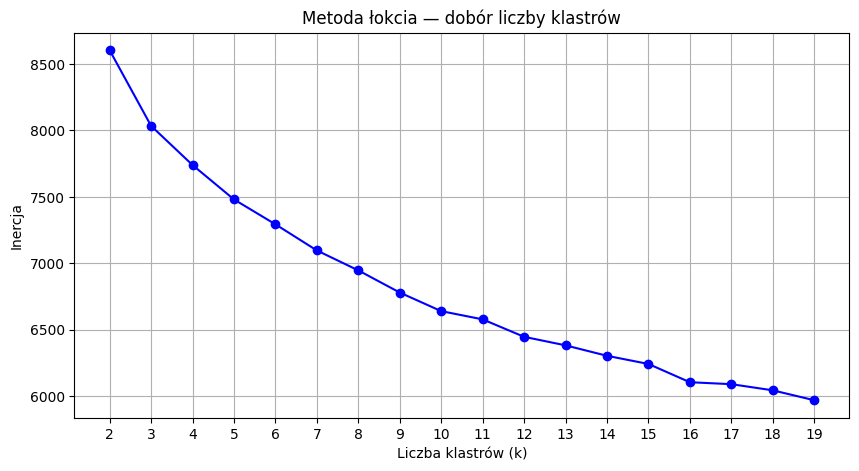

In [ ]:
inertia = []
K = range(2, 20)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K, inertia, "bo-")
plt.xlabel("Liczba klastrów (k)")
plt.ylabel("Inercja")
plt.title("Metoda łokcia — dobór liczby klastrów")
plt.xticks(K)
plt.grid(True)

Zastosujmy algorytm centroidów dla 8 skupień. Niestety skupienie/klaster 0 to typowy worek na śmieci - trafia tu wszystko co nie wiadomo jak zaklasyfikować - liczba rekomendacji powinna być podobna w poszczególnych skupieniach

In [ ]:
k = 8
km = KMeans(n_clusters=k, random_state=42, n_init=10)
df["klaster"] = km.fit_predict(X)

# Podgląd liczebności klastrów
print(df["klaster"].value_counts().sort_index())

klaster
0    68
1    31
2    46
3    57
4    18
5    38
6    20
7    20
Name: count, dtype: int64


In [ ]:
for i in range(k):
    print(f"\n{'='*60}")
    print(f"KLASTER {i} ({len(df[df['klaster']==i])} rekomendacji)")
    print('='*60)
    for _, row in df[df["klaster"] == i].head(3).iterrows():
        print(f"  • {row['Rekomendacja'][:120]}...")


KLASTER 0 (68 rekomendacji)
  • Samoistne wartości lasu, wynikające z jego wpływu na stan środowiska i warunki życia, oraz liczne funkcje gospodarcze i ...
  • Wartość produkcyjna/gospodarcza lasów powinna służyć gospodarczemu rozwojowi kraju i być głównym źródłem finansowania dz...
  • Należy nadać lasom właściwą im rangę w gospodarczo-społecznym rozwoju i bezpieczeństwie ekologicznym państwa. Pomimo że ...

KLASTER 1 (31 rekomendacji)
  • Mamy do czynienia z pluralizmem antropologicznym, koncepcjami przyrody alternatywnej, zróżnicowaniem aksjologicznym i ró...
  • Ekosystem leśny/las nie jest jedynie przedmiotem i narzędziem gospodarki leśnej, ale również jej celem, dlatego gospodar...
  • Potrzebna jest definicja wielofunkcyjnego leśnictwa i jego kodyfikacja w regulacja prawnych. Do zasad i instrukcji należ...

KLASTER 2 (46 rekomendacji)
  • Lasy państwowe są własnością publiczną, wspólnym dobrem obywateli, zasobem strategicznym o charakterze narodowym. Jako ż...
  • Wizja przyszł

KlasternProponowana nazwa052Filozofia i wartości lasu126Wielofunkcyjność i regulacje prawne229Klimat, węgiel i monitoring328Gospodarka drewnem i biomasa437Hodowla lasu i ochrona gatunków533Lasy państwowe i funkcje społeczne676⚠️ Zbyt ogólny — do rozbicia717Zarządzanie, polityka i turystyka Klaster 6 wymaga rozbicia — trzy przykładowe rekomendacje dotyczą zupełnie różnych rzeczy: wartości ekologicznych, produkcji gospodarczej i bezpieczeństwa ekologicznego państwa. To klasyczny "kosz na resztki".

### Dendrogram

Metodyka wyliczenia dendrogramu:
https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html

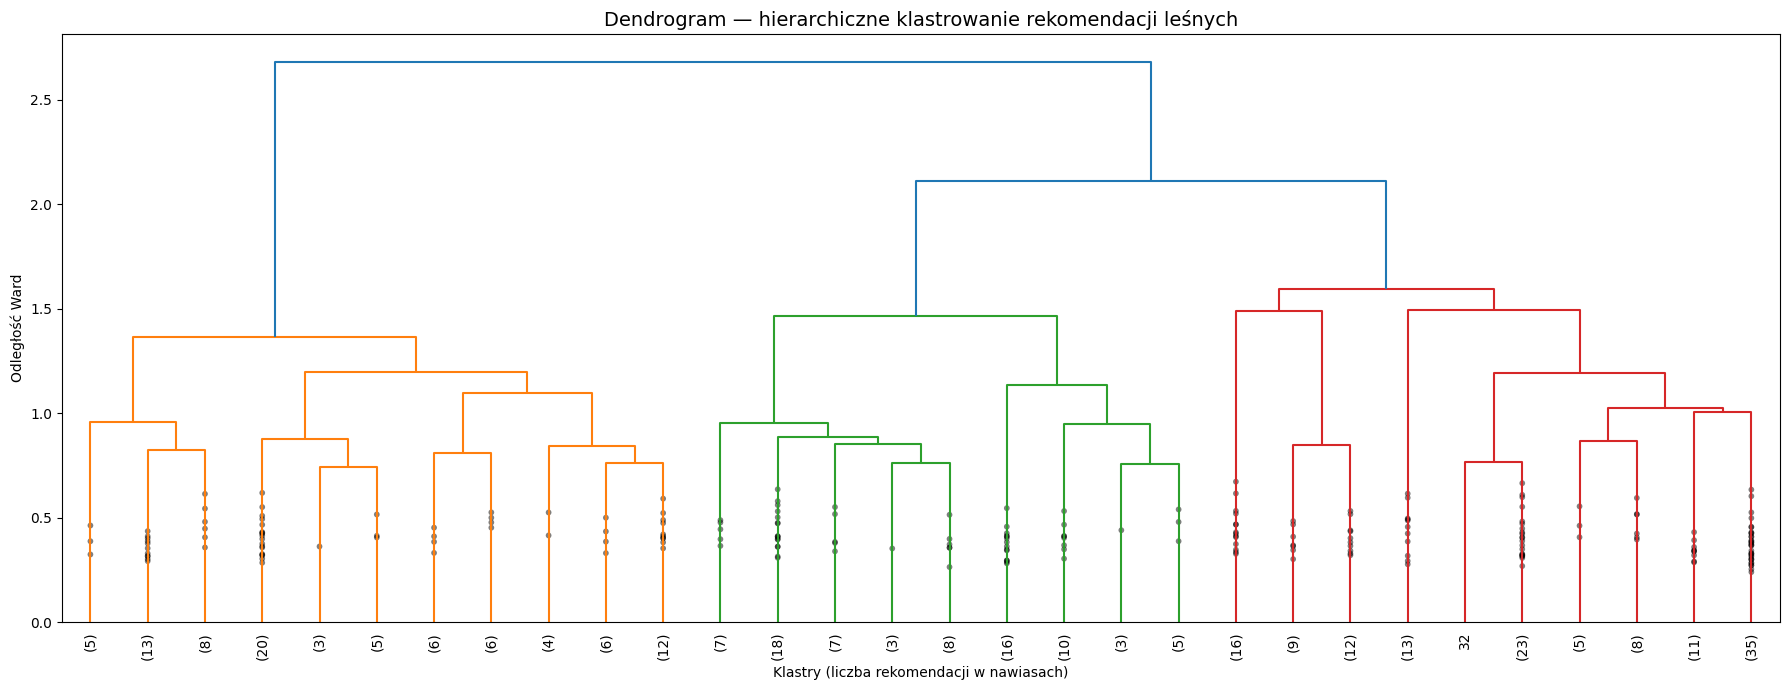

In [ ]:
# Normalizacja wektorów przed klastrowaniem hierarchicznym
X_norm = normalize(X)

# Obliczenie macierzy połączeń (ward minimalizuje wariancję wewnątrz klastrów)
Z = linkage(X_norm, method="ward")

# Rysowanie dendrogramu
plt.figure(figsize=(18, 7))
dendrogram(
    Z,
    truncate_mode="lastp",   # pokazuje tylko ostatnie p połączeń
    p=30,                    # liczba wyświetlanych węzłów
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
)
plt.title("Dendrogram — hierarchiczne klastrowanie rekomendacji leśnych", fontsize=14)
plt.xlabel("Klastry (liczba rekomendacji w nawiasach)")
plt.ylabel("Odległość Ward")
plt.tight_layout()
plt.show()

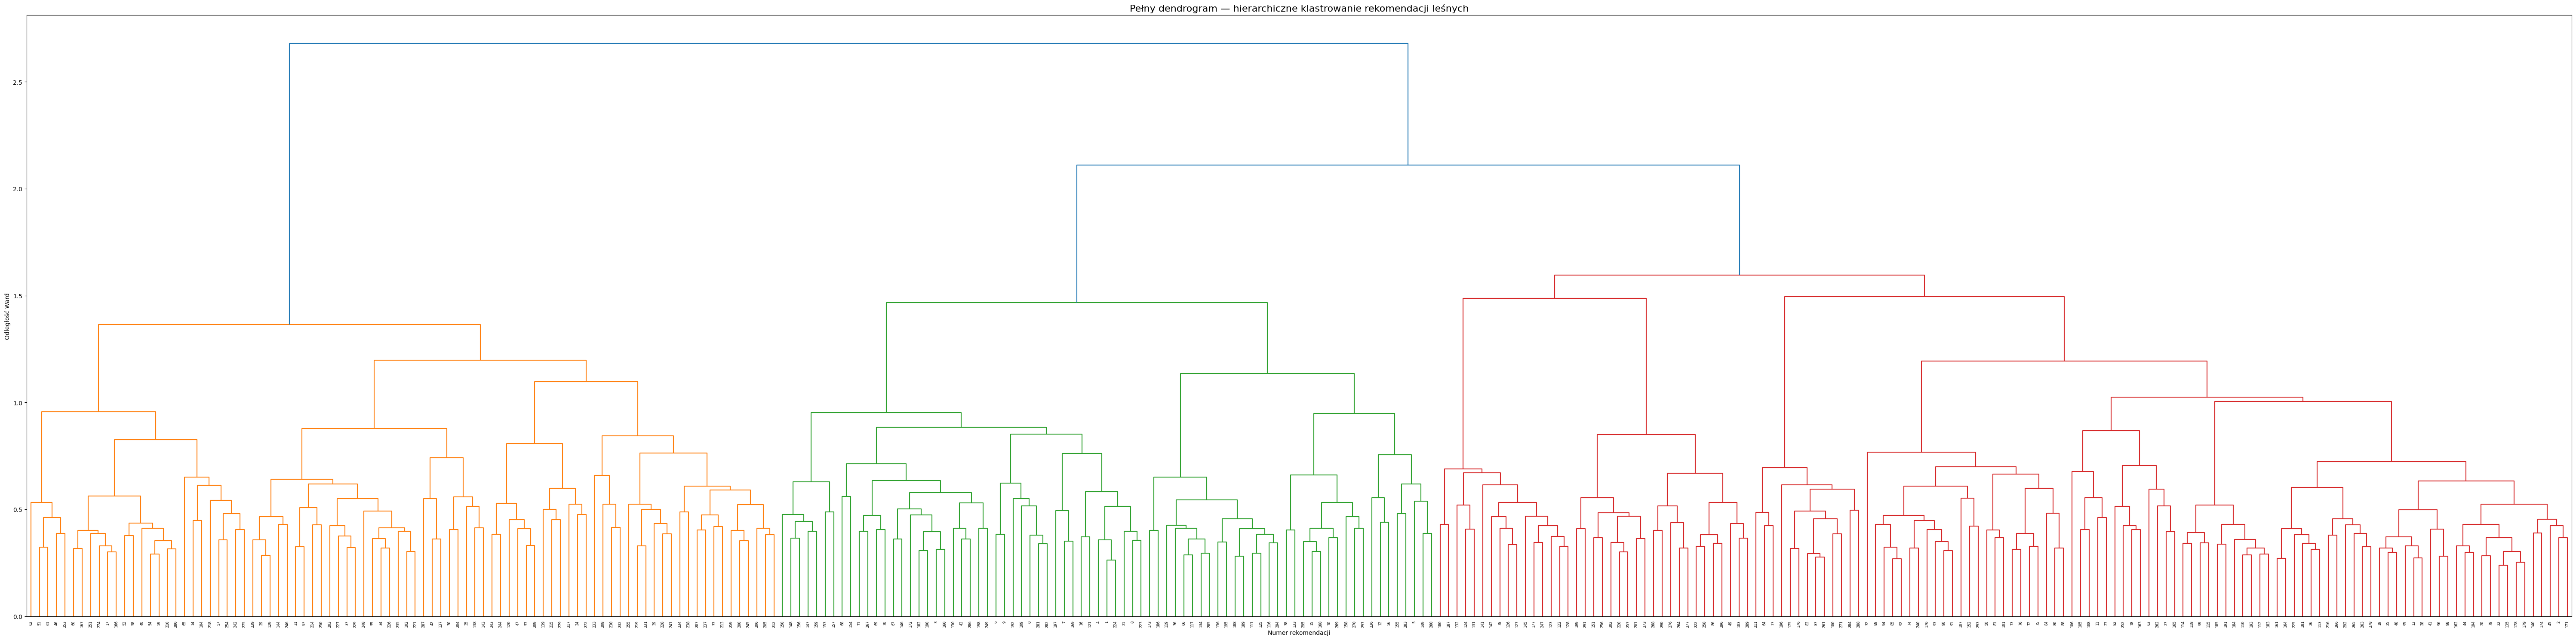

In [ ]:
X_norm = normalize(X)
Z = linkage(X_norm, method="ward")

plt.figure(figsize=(60, 15))
dendrogram(
    Z,
    leaf_rotation=90,
    leaf_font_size=6,
    show_leaf_counts=True,    # pokazuje liczby obserwacji w węzłach
    color_threshold=0.7 * max(Z[:, 2]),  # automatyczne kolorowanie klastrów
)
plt.title("Pełny dendrogram — hierarchiczne klastrowanie rekomendacji leśnych", fontsize=16)
plt.xlabel("Numer rekomendacji")
plt.ylabel("Odległość Ward")
plt.tight_layout()

### PCA

In [ ]:
pca = PCA(n_components = 2, random_state = 42)
coords = pca.fit_transform(X)

In [ ]:
pattern = r'\[([A-ZĄĆĘŁŃÓŚŹŻ]+)\s*-\s*([A-ZĄĆĘŁŃÓŚŹŻ]+)'

df.Rekomendacja = df.Rekomendacja.str.replace(pattern, r'[\1\2', regex=True)

In [ ]:
pattern = r'\[([A-ZĄĆĘŁŃÓŚŹŻ]+),'

df['Ryk_label'] = df.Rekomendacja.str.findall(pattern)

In [ ]:
# Spłaszcz listę list w kolumnie 'Ryk_label' i uzyskaj unikalne elementy
df['Ryk_label_'] = [label for sublist in df['Ryk_label'] for label in sublist]


Rekomendacje są semantycznie bardzo podobne - stąd widzimy silne przenikanie się poszczególnych rekomendacji i brak wyraźnych skupień (konsekwencja języka eksperckiego i długich wywodów). Im bliżej są dane punkty tym ich semantyka jest bardziej podobna

/tmp/ipykernel_2796/197138580.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", n_kategorii)


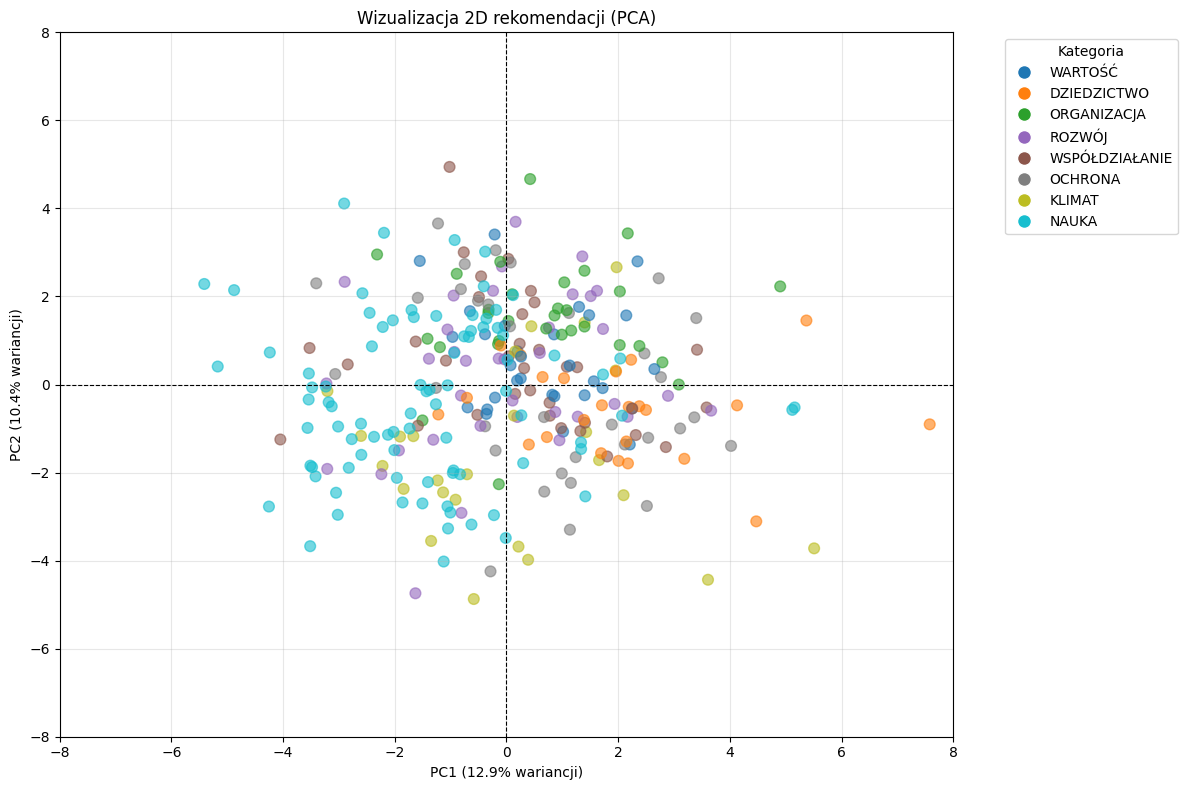

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))


colors_numeric, kategorie = pd.factorize(df['Ryk_label_'])
n_kategorii = len(kategorie)

cmap = plt.cm.get_cmap("tab10", n_kategorii)

scatter = ax.scatter(
    coords[:, 0],
    coords[:, 1],
    alpha=0.6,
    s=60,
    c=colors_numeric,
    cmap=cmap,
    vmin=-0.5,
    vmax=n_kategorii - 0.5
)

# Legenda zamiast colorbar
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cmap(i), markersize=10, label=kat)
    for i, kat in enumerate(kategorie)
]
ax.legend(handles=handles, title="Kategoria", bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} wariancji)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} wariancji)")
ax.set_title("Wizualizacja 2D rekomendacji (PCA)")
ax.grid(True, alpha=0.3)

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.xlim(-8,8)
plt.ylim(-8,8)

plt.tight_layout()

Poniżej wykres PCA w wersjii interaktywnej - można podejrzeć jaki jest numer poszczególnych rekomendacji w przestrzeni 2D

In [ ]:
plot_df = pd.DataFrame(coords, columns=['PC1', 'PC2'])
plot_df['Kategoria'] = df['Ryk_label_'].values
plot_df['Rekomendacja'] = df['Nr rekomendacji'].values

fig = px.scatter(
    plot_df,          # ← plot_df zamiast coords
    x='PC1',          # ← nazwa kolumny zamiast 0
    y='PC2',          # ← nazwa kolumny zamiast 1
    color='Kategoria',
    hover_data=['Rekomendacja'],
    labels={
        'PC1': 'PC1 (12.9% wariancji)',
        'PC2': 'PC2 (10.4% wariancji)',
        'color': 'Kategoria'
    },
    title='Wizualizacja 2D rekomendacji (PCA)'
)

fig.update_layout(
    xaxis=dict(range=[-8, 8]),
    yaxis=dict(range=[-6, 6]),
)

fig.show()

In [ ]:
labels = np.array([label for sublist in df['Ryk_label'] for label in sublist]).reshape(-1,1)

In [ ]:
centroid = pd.DataFrame(np.hstack((coords, labels)), columns=['PC1', 'PC2', 'label'])

In [ ]:
centroid = centroid.astype({'PC1': float,
                            'PC2': float})

In [ ]:
centroid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298 entries, 0 to 297
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PC1     298 non-null    float64
 1   PC2     298 non-null    float64
 2   label   298 non-null    object 
dtypes: float64(2), object(1)
memory usage: 7.1+ KB


In [ ]:
centroid = centroid.groupby('label', as_index=False).mean()

/tmp/ipykernel_2796/3335729219.py:7: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



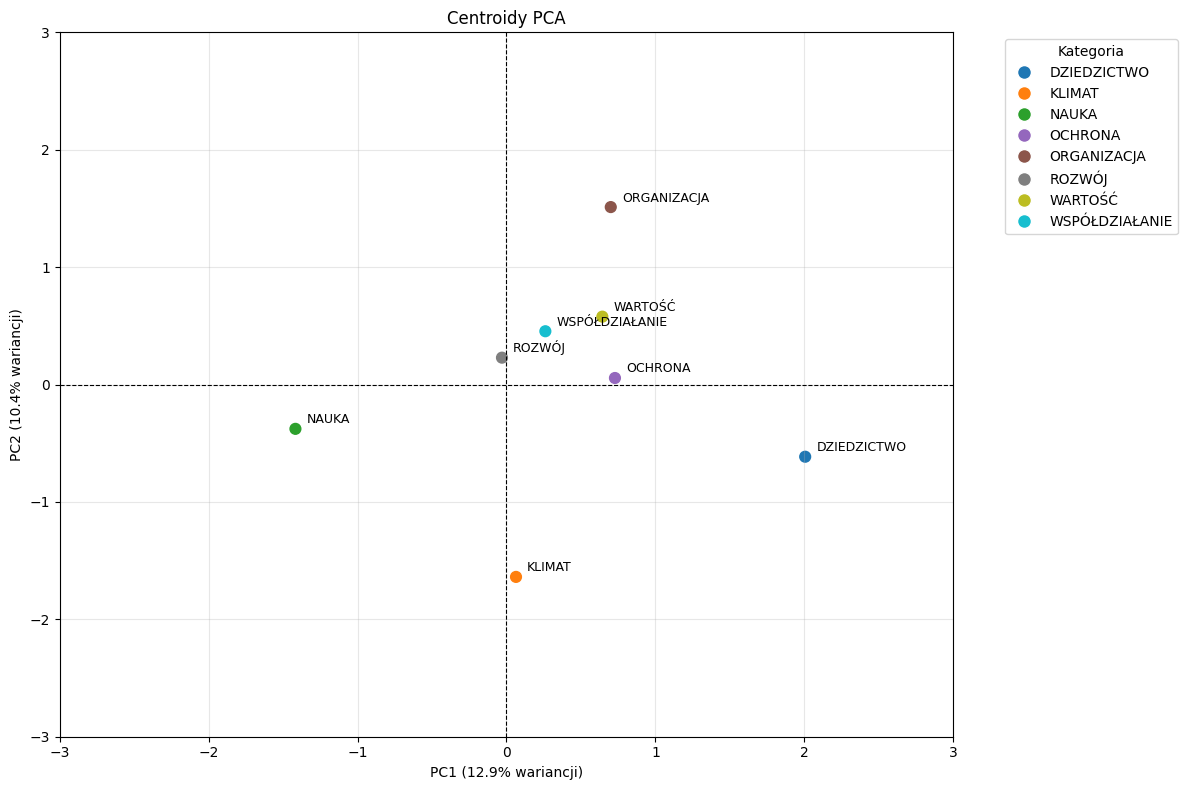

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))


colors_numeric, kategorie = pd.factorize(centroid['label'])
n_kategorii = len(kategorie)

cmap = plt.cm.get_cmap("tab10", n_kategorii)

scatter = ax.scatter(
    centroid['PC1'],
    centroid['PC2'],
    alpha=1,
    s=60,
    c=colors_numeric,
    cmap=cmap,
    vmin=-0.5,
    vmax=n_kategorii - 0.5
)

# Legenda zamiast colorbar
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cmap(i), markersize=10, label=kat)
    for i, kat in enumerate(kategorie)
]

for _, row in centroid.iterrows():
    ax.annotate(row['label'], (row['PC1'], row['PC2']),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.legend(handles=handles, title="Kategoria", bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} wariancji)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} wariancji)")
ax.set_title("Centroidy PCA")
ax.grid(True, alpha=0.3)

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.xlim(-3,3)
plt.ylim(-3,3)

plt.tight_layout()

In [ ]:
def confidence_ellipse(x, y, ax, n_std=3.0, facecolor='none', **kwargs):

    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])

    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)


    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)


    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

Komentarz do analizy PCA: Elipsy obejmują 68% obserwacji (1SD). Zdaję sobie sprawę,e przy takiej liczbie kategorii czytelnosć jest stosunkowo słaba. Kategorie które model dobrze oddziela pod względem semantycznym to: NAUKA, KLIMAT, ORGANIZACJA i DZIEDZICTWO. Kategorie problematyczne to WARTOŚĆ, WSPÓŁDZIAŁANIE, ROZWÓJ, OCHRONA (podobna semantyka)

/tmp/ipykernel_2796/2946059394.py:5: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



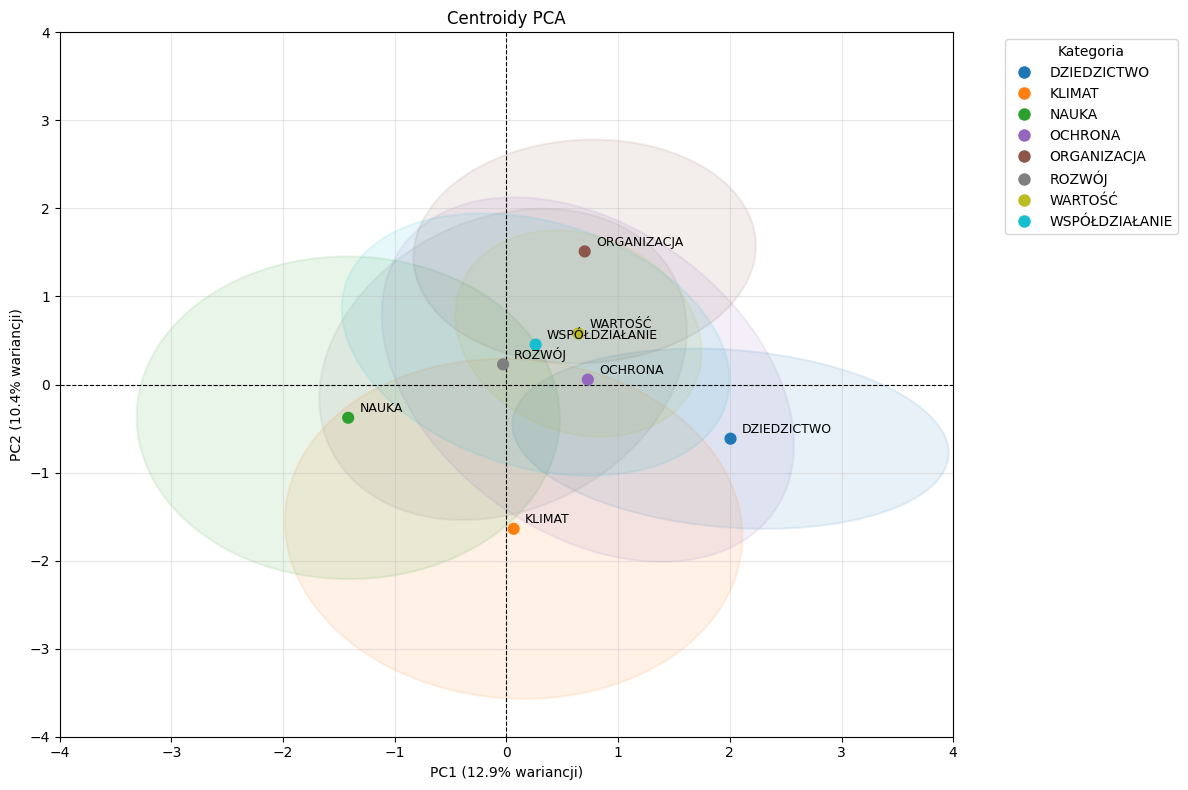

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

colors_numeric, kategorie = pd.factorize(centroid['label'])
n_kategorii = len(kategorie)
cmap = plt.cm.get_cmap("tab10", n_kategorii)

for i, kat in enumerate(kategorie):
    maska = plot_df['Kategoria'] == kat
    x = plot_df.loc[maska, 'PC1'].values
    y = plot_df.loc[maska, 'PC2'].values

    if len(x) > 2:
        kolor = cmap(i)
        confidence_ellipse(
            x, y, ax,
            n_std=1.0,
            edgecolor=kolor,
            facecolor=kolor,
            alpha=0.1,
            linewidth=1.5
        )

scatter = ax.scatter(
    centroid['PC1'],
    centroid['PC2'],
    alpha=1,
    s=60,
    c=colors_numeric,
    cmap=cmap,
    vmin=-0.5,
    vmax=n_kategorii - 0.5,
    zorder=5  # na wierzchu
)


for _, row in centroid.iterrows():
    ax.annotate(row['label'], (row['PC1'], row['PC2']),
                textcoords="offset points", xytext=(8, 4), fontsize=9, zorder = 6)


handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cmap(i), markersize=10, label=kat)
    for i, kat in enumerate(kategorie)
]
ax.legend(handles=handles, title="Kategoria", bbox_to_anchor=(1.05, 1), loc='upper left')

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} wariancji)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} wariancji)")
ax.set_title("Centroidy PCA")
ax.grid(True, alpha=0.3)

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.tight_layout()

### Grupy robocze

In [ ]:
df1 = pd.read_excel('https://raw.githubusercontent.com/Petroselinum/NPL/main/numeracja_kor.xlsx').iloc[:,1:]
df1.head()

,Grupa_1,Grupa_2,Grupa_3,Grupa_4
0,2.0,NaN,NaN,NaN
1,2.0,NaN,NaN,NaN
2,2.0,NaN,NaN,NaN
3,4.0,5.0,2.0,NaN
4,2.0,4.0,NaN,NaN


In [ ]:
df1 = df1.dropna(how='all')
df1

,Grupa_1,Grupa_2,Grupa_3,Grupa_4
0,2.0,NaN,NaN,NaN
1,2.0,NaN,NaN,NaN
2,2.0,NaN,NaN,NaN
3,4.0,5.0,2.0,NaN
4,2.0,4.0,NaN,NaN
...,...,...,...,...
498,5.0,4.0,NaN,NaN
499,5.0,4.0,NaN,NaN
502,5.0,NaN,NaN,NaN
509,5.0,NaN,NaN,NaN


In [ ]:
df1 = df1.apply(lambda x: pd.Series(sorted(x, key=lambda v: (pd.isna(v), v))), axis=1)
df1.head()

,0,1,2,3
0,2.0,NaN,NaN,NaN
1,2.0,NaN,NaN,NaN
2,2.0,NaN,NaN,NaN
3,2.0,4.0,5.0,NaN
4,2.0,4.0,NaN,NaN


In [ ]:
df1 = df1.astype(str)
df1.head()

,0,1,2,3
0,2.0,nan,nan,nan
1,2.0,nan,nan,nan
2,2.0,nan,nan,nan
3,2.0,4.0,5.0,nan
4,2.0,4.0,nan,nan


In [ ]:
df_dummies = pd.get_dummies(df1)

In [ ]:
df_dummies = df_dummies[[col for col in df_dummies.columns if not col.__contains__('nan')]]

In [ ]:
df_dummies.columns = [col[2:] for col in df_dummies.columns]
df_dummies

,1.0,2.0,3.0,4.0,5.0,2.0,3.0,4.0,5.0,3.0,4.0,5.0,4.0,5.0
0,False,True,False,False,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,False,False,False,False
3,False,True,False,False,False,False,False,True,False,False,False,True,False,False
4,False,True,False,False,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,False,False,False,True,False,False,False,False,True,False,False,False,False,False
499,False,False,False,True,False,False,False,False,True,False,False,False,False,False
502,False,False,False,False,True,False,False,False,False,False,False,False,False,False
509,False,False,False,False,True,False,False,False,False,False,False,False,False,False


In [ ]:
df_dummies = df_dummies.T.groupby(df_dummies.columns).any().T

In [ ]:
df_dummies = df_dummies.reset_index().iloc[:,1:]
df_dummies

,1.0,2.0,3.0,4.0,5.0
0,False,True,False,False,False
1,False,True,False,False,False
2,False,True,False,False,False
3,False,True,False,True,True
4,False,True,False,True,False
...,...,...,...,...,...
293,False,False,False,True,True
294,False,False,False,True,True
295,False,False,False,False,True
296,False,False,False,False,True


In [ ]:
X.shape

(298, 300)

In [ ]:
df_dummies.shape

(298, 5)

In [ ]:
pca = PCA(n_components = 2, random_state = 42)
coords = pca.fit_transform(X)

In [ ]:
pd.DataFrame(coords, columns=['PC1', 'PC2'])

,PC1,PC2
0,0.255814,0.139743
1,-0.344110,-0.566242
2,0.198331,0.753251
3,2.498168,-0.576612
4,0.850877,1.138965
...,...,...
293,0.859591,0.659664
294,2.038051,0.590893
295,-0.007219,-0.147163
296,-1.257323,1.557968


In [ ]:
labels = np.array([label for sublist in df['Ryk_label'] for label in sublist]).reshape(-1,1)
labels = pd.DataFrame(labels, columns = ['Ryk'])

In [ ]:
data = pd.concat([pd.DataFrame(coords,
                        columns=['PC1', 'PC2']),
            df_dummies,
            labels], axis = 1)

In [ ]:
data

,PC1,PC2,1.0,2.0,3.0,4.0,5.0,Ryk
0,0.255814,0.139743,False,True,False,False,False,WARTOŚĆ
1,-0.344110,-0.566242,False,True,False,False,False,WARTOŚĆ
2,0.198331,0.753251,False,True,False,False,False,WARTOŚĆ
3,2.498168,-0.576612,False,True,False,True,True,DZIEDZICTWO
4,0.850877,1.138965,False,True,False,True,False,WARTOŚĆ
...,...,...,...,...,...,...,...,...
293,0.859591,0.659664,False,False,False,True,True,NAUKA
294,2.038051,0.590893,False,False,False,True,True,NAUKA
295,-0.007219,-0.147163,False,False,False,False,True,NAUKA
296,-1.257323,1.557968,False,False,False,False,True,NAUKA


In [ ]:
#Wyciągamy rekomendacje co do których klasyfikacji jesteśmy pewni

kat = ['1.0','2.0','3.0','4.0','5.0']

adam = pd.DataFrame()

for i in kat:
    subset = data[(data[i] == True) & (~data[[col for col in kat if col != i]].any(axis=1))]
    adam = pd.concat([adam, subset], axis = 0)

In [ ]:
adam

,PC1,PC2,1.0,2.0,3.0,4.0,5.0,Ryk
29,-0.381887,-0.948380,True,False,False,False,False,OCHRONA
30,0.215137,-3.681944,True,False,False,False,False,KLIMAT
31,-1.841844,-2.370523,True,False,False,False,False,KLIMAT
32,1.955399,0.317985,True,False,False,False,False,KLIMAT
34,-0.706592,-2.038461,True,False,False,False,False,KLIMAT
...,...,...,...,...,...,...,...,...
290,-4.878047,2.144412,False,False,False,False,True,NAUKA
291,-0.928319,3.282311,False,False,False,False,True,NAUKA
292,-0.758142,1.094662,False,False,False,False,True,NAUKA
295,-0.007219,-0.147163,False,False,False,False,True,NAUKA


In [ ]:
adam['label'] = adam[kat].idxmax(axis=1)
adam

,PC1,PC2,1.0,2.0,3.0,4.0,5.0,Ryk,label
29,-0.381887,-0.948380,True,False,False,False,False,OCHRONA,1.0
30,0.215137,-3.681944,True,False,False,False,False,KLIMAT,1.0
31,-1.841844,-2.370523,True,False,False,False,False,KLIMAT,1.0
32,1.955399,0.317985,True,False,False,False,False,KLIMAT,1.0
34,-0.706592,-2.038461,True,False,False,False,False,KLIMAT,1.0
...,...,...,...,...,...,...,...,...,...
290,-4.878047,2.144412,False,False,False,False,True,NAUKA,5.0
291,-0.928319,3.282311,False,False,False,False,True,NAUKA,5.0
292,-0.758142,1.094662,False,False,False,False,True,NAUKA,5.0
295,-0.007219,-0.147163,False,False,False,False,True,NAUKA,5.0


In [ ]:
adam_pca = adam.groupby('label', as_index=False).agg({'PC1': 'mean', 'PC2': 'mean'})
adam_pca

,label,PC1,PC2
0,1.0,-0.016481,-1.937419
1,2.0,1.033801,-0.235865
2,3.0,-1.331025,-0.016025
3,4.0,0.816580,1.419287
4,5.0,-0.871748,0.192009


In [ ]:
ryk_pca = adam.groupby('Ryk', as_index=False).agg({'PC1': 'mean', 'PC2': 'mean'})
ryk_pca

,Ryk,PC1,PC2
0,DZIEDZICTWO,2.507651,-0.789982
1,KLIMAT,-0.332231,-2.124937
2,NAUKA,-1.453540,0.516736
3,OCHRONA,0.807877,-0.072818
4,ORGANIZACJA,0.946791,1.931000
5,ROZWÓJ,-0.400540,0.042596
6,WARTOŚĆ,0.501796,0.776011
7,WSPÓŁDZIAŁANIE,0.243403,0.884726


UWAGA! Poniższy wykres nieco przebudowałem bo strzałki były mylące - mało tego moja interpretacja wyniku była wcześniej błędna. W tym przypadku nie ma mowy o żadnych korelacjach - to nie jest biplot! Jedyne co nas interesuje to odległości między centroidami. Im dane centroidy są bliżej siebie tym dane kategorie są bardziej podobne pod względem semantycznym - im dalej tym są semantycznie bardziej różne. Uwaga: Wektory spaCy dobrze radzą sobie z semantyką na poziomie słowa, ale słabo na poziomie zdania i kontekstu. W tym przypadku bazowano wyłącznie na rekomendacjach, które Adam przypisał do tylko jednej grupy roboczej - ok 140 przypadków. Najlepiej 'siadły' grupa Marzeny i Pana prof. Czerepko. Trochę słabo wyszło z tym dziedzictwem - widać, że za bardzo nie było pomysłu jak to przyporządkowywać - ogólnie można by zrobić osobną grupę dla dziedzictwa ale wiadomo, że nie będzie bo jesteśmy na dalszym etapie. Dziedzictwo semantycznie jest najbliżej grupy Pana prof. Czerepko. Generalnie poza grupą 3, w mojej ocenie, wszystkie pozostałe są zlokalizowane zgodnie z ich obszarem tematycznym
- Reasumując wykres dowodzi, że Obie klasyfikacje są semantycznie spójne — eksperci niezależnie doszli do podobnych kategorii, co potwierdza że podział jest merytoryczny, nie arbitralny.
- Największa niezgodność — grupa 3.0:
Grupa robocza 3 to drewno i ekonomika — a model plasuje ją blisko NAUKA (lewo). To sugeruje że rekomendacje o drewnie używają języka technicznego/analitycznego, który semantycznie brzmi podobnie do języka naukowego.
- DZIEDZICTWO nie ma odpowiednika w grupach roboczych — ale patrząc na strukturę grup, treści kulturowe i historyczne są rozproszone w grupie 2 (ochrona wartości kulturowych)
- Model potwierdza że podział na grupy robocze jest merytorycznie uzasadniony — KLIMAT i OCHRONA są semantycznie odrębne, co widać w przestrzeni PCA. To dobry argument że klasyfikacja ekspercka ma podstawy w samej treści rekomendacji.

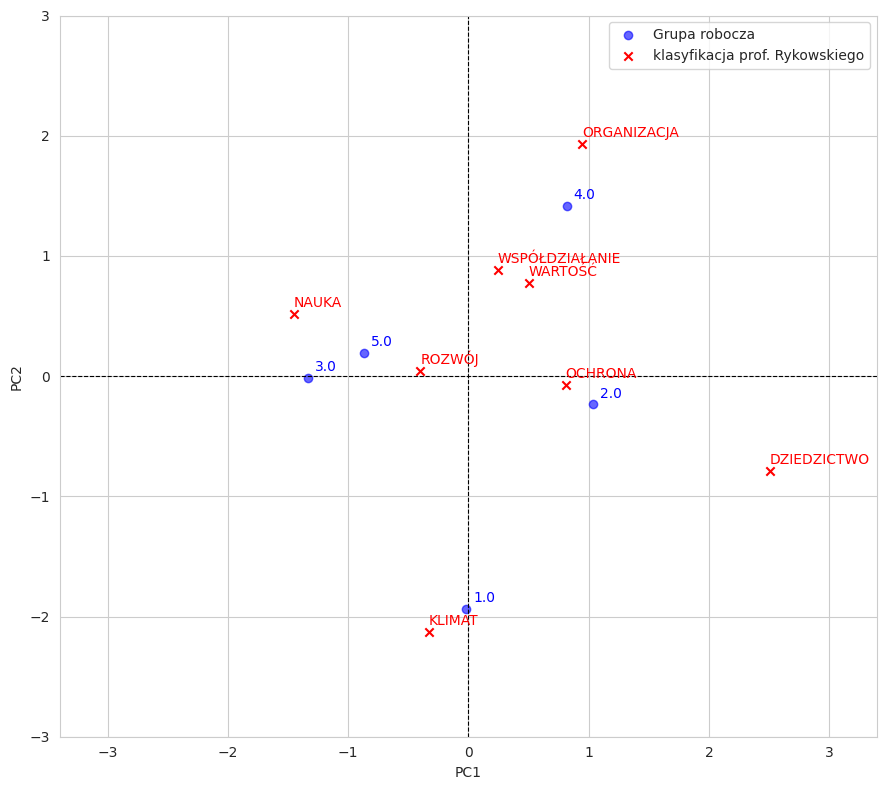

In [ ]:
# 1. Tworzymy pierwszy DataFrame (Obserwacje)
df_obs = adam_pca
df_feat = ryk_pca

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

plt.scatter(df_obs['PC1'], df_obs['PC2'], color='blue', alpha=0.6, label='Grupa robocza')

for i, txt in enumerate(df_obs['label']):
    #plt.arrow(0, 0, df_obs['PC1'][i], df_obs['PC2'][i], color='blue', alpha=0.3, head_width=0.05)
    plt.annotate(txt, (df_obs['PC1'][i], df_obs['PC2'][i]), xytext=(5,5), textcoords='offset points', color='blue')


plt.scatter(df_feat['PC1'], df_feat['PC2'], color='red', marker='x', label='klasyfikacja prof. Rykowskiego')

for i in range(len(df_feat)):
    #plt.arrow(0, 0, df_feat['PC1'][i], df_feat['PC2'][i], color='red', alpha=0.3, head_width=0.05)
    plt.annotate(df_feat['Ryk'][i], (df_feat['PC1'][i], df_feat['PC2'][i]), xytext=(0, 5), textcoords='offset points', color='red')

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.xlim(-3.4,3.4)
plt.ylim(-3,3)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.gca().set_aspect('equal', adjustable='box')

In [ ]:
# Grupa 3 ma mało rekomendacji

adam.query('label == "3.0"')

,PC1,PC2,1.0,2.0,3.0,4.0,5.0,Ryk,label
14,-3.526525,0.829752,False,False,True,False,False,WSPÓŁDZIAŁANIE,3.0
24,-1.388839,0.586188,False,False,True,False,False,ROZWÓJ,3.0
51,-2.240564,-2.036273,False,False,True,False,False,ROZWÓJ,3.0
57,-2.842709,0.456457,False,False,True,False,False,WSPÓŁDZIAŁANIE,3.0
60,-3.224083,0.024445,False,False,True,False,False,ROZWÓJ,3.0
61,-3.209890,-1.916810,False,False,True,False,False,ROZWÓJ,3.0
62,-1.630659,-4.741631,False,False,True,False,False,ROZWÓJ,3.0
63,-0.133089,0.989348,False,False,True,False,False,ORGANIZACJA,3.0
64,-1.191847,0.848460,False,False,True,False,False,ORGANIZACJA,3.0
66,2.892951,-0.256445,False,False,True,False,False,ROZWÓJ,3.0


### model klasyfikacyjny

#### SVM

In [ ]:
embedings = X[list(adam.index),:]
labels = list(adam.label)

SVC - maszyna wektorów nośnych bo najlepiej skaluje się do małych zbiorów danych

In [ ]:
model = SVC(kernel='rbf', class_weight='balanced')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, embedings, labels, cv=cv, scoring='f1_weighted')
print("f1: ", scores.mean(), ", std:",scores.std())

f1:  0.7098280189268691 , std: 0.08475850220468459


0.71 — średnia F1 z 5 foldów
0.085 — odchylenie standardowe, czyli wyniki wahają się między ~0.62 a ~0.80

In [ ]:
y_pred = cross_val_predict(model,embedings, labels, cv=cv)
print(classification_report(labels, y_pred))

              precision    recall  f1-score   support

         1.0       0.48      0.83      0.61        12
         2.0       0.61      0.61      0.61        41
         3.0       0.73      0.85      0.79        13
         4.0       0.79      0.62      0.70        37
         5.0       0.88      0.81      0.85        37

    accuracy                           0.71       140
   macro avg       0.70      0.74      0.71       140
weighted avg       0.73      0.71      0.71       140



In [ ]:
#Dostrajanie modelu
params = {'C': [0.1, 1, 2, 2.5, 3, 3.5, 4, 5, 6, 7, 8],
          'gamma': ['scale', 'auto', 0.001, 0.01],
          'kernel': ['linear', 'poly', 'rbf', 'sigmoid']}
grid = GridSearchCV(SVC(class_weight='balanced'), params, cv=cv, scoring='f1_weighted')
grid.fit(embedings, labels)
print(grid.best_params_, grid.best_score_)

{'C': 3, 'gamma': 0.01, 'kernel': 'rbf'} 0.7830580801821403


In [ ]:
#Dostrojony model działa lepiej ale klasa 1 nadal jest problematyczna - tylko 12 próbek

model = SVC(class_weight='balanced', **grid.best_params_)

y_pred = cross_val_predict(model, embedings, labels, cv=cv)
print(classification_report(labels, y_pred))

              precision    recall  f1-score   support

         1.0       0.67      0.67      0.67        12
         2.0       0.70      0.73      0.71        41
         3.0       0.67      0.77      0.71        13
         4.0       0.83      0.78      0.81        37
         5.0       0.94      0.89      0.92        37

    accuracy                           0.79       140
   macro avg       0.76      0.77      0.76       140
weighted avg       0.79      0.79      0.79       140



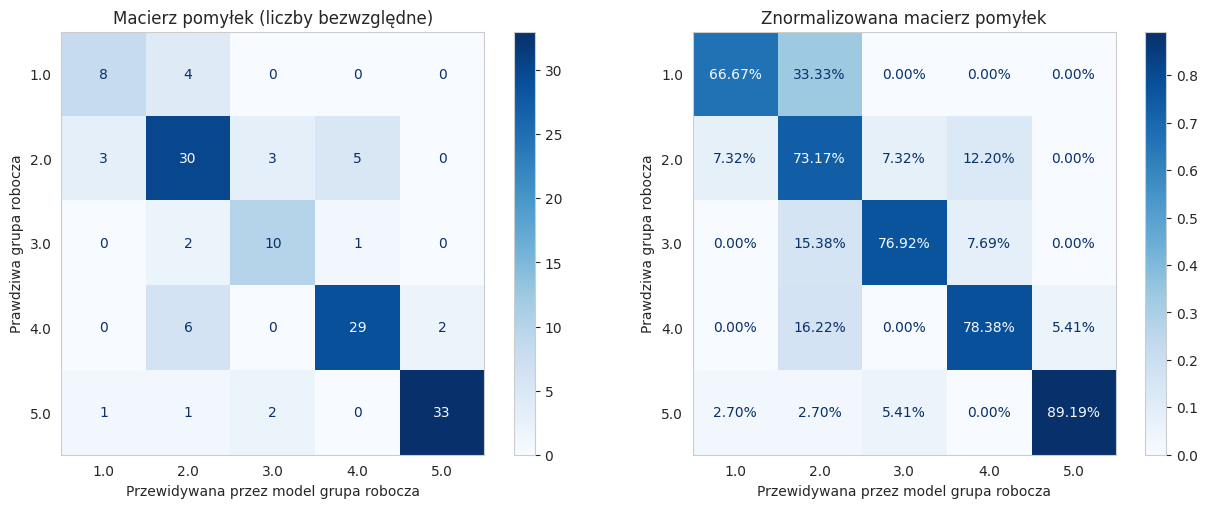

In [ ]:
class_labels = np.unique(labels)  # zamiast model.classes_

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, normalize, title in zip(
    axes,
    [None, 'true'],
    ['Macierz pomyłek (liczby bezwzględne)', 'Znormalizowana macierz pomyłek']
):
    cm = confusion_matrix(labels, y_pred, normalize=normalize)
    fmt = 'd' if normalize is None else '.2%'
    ConfusionMatrixDisplay(cm, display_labels=class_labels).plot(
        ax=ax, cmap='Blues', colorbar=True, values_format=fmt  # <-- colorbar=True
    )
    ax.set_title(title)
    ax.grid(False)
    ax.set_ylabel('Prawdziwa grupa robocza')
    ax.set_xlabel('Przewidywana przez model grupa robocza')

plt.tight_layout()

In [ ]:
scores = cross_val_score(model, embedings, labels, cv=cv, scoring='f1_weighted')
print("f1: ", scores.mean(), ", std:",scores.std())

f1:  0.7830580801821403 , std: 0.061837141719825905


In [ ]:
scores = cross_val_score(model, embedings, labels, cv=cv, scoring='accuracy')
print("accuracy: ", scores.mean(), ", std:",scores.std())

accuracy:  0.7857142857142858 , std: 0.05976143046671965


In [ ]:
# Chcemy by model zwracał prawdopodobieństwo przynależności rekomendacji do grup roboczych
model = SVC(class_weight='balanced', **grid.best_params_, probability=True).fit(embedings, labels)

In [ ]:
#Embedingi rekomendacji których grupy roboczej nie znamy
data_pred = X[list(data.index[~data.index.isin(list(adam.index))]),:]

In [ ]:
#Dodajemy 1 bo python indexuje od 0
rekom_nr = np.array(data.index[~data.index.isin(list(adam.index))]) + 1

In [ ]:
res_proba = model.predict_proba(data_pred)

In [ ]:
res = model.predict(data_pred).reshape(-1,1)
rekom_nr = rekom_nr.reshape(-1,1)

In [ ]:
#Pewność prognozy

df = pd.DataFrame(res_proba, columns=[f'class_{c}' for c in model.classes_])

# Top 1 i Top 2 prawdopodobieństwa
top2 = np.sort(res_proba, axis=1)[:, ::-1][:, :2]  # dwie najwyższe wartości

df['top1_prob']   = top2[:, 0]
df['top2_prob']   = top2[:, 1]
df['margin']      = top2[:, 0] - top2[:, 1]  # różnica między top1 a top2
df['pred_class']  = model.classes_[np.argmax(res_proba, axis=1)]

# Progi - dopasujesz do swoich danych
CERTAIN_THRESHOLD   = 0.80  # top1 > 80% → pewna predykcja
UNCERTAIN_THRESHOLD = 0.15  # margin < 15% → niepewna predykcja

df['verdict'] = 'normal'
df.loc[df['top1_prob'] >= CERTAIN_THRESHOLD, 'verdict'] = 'certain'
df.loc[df['margin'] <= UNCERTAIN_THRESHOLD,  'verdict'] = 'uncertain'

# Wyniki
certain   = df[df['verdict'] == 'certain']
uncertain = df[df['verdict'] == 'uncertain']

In [ ]:
pewnosc = np.array(df.verdict).reshape(-1,1)

In [ ]:
pd.DataFrame(np.concat([rekom_nr, res, res_proba, pewnosc], axis = 1)).to_excel('SVM_res.xlsx')

#### RandomForest

In [ ]:
model = RandomForestClassifier(class_weight='balanced')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, embedings, labels, cv=cv, scoring='f1_weighted')
print("f1: ", scores.mean(), ", std:",scores.std())

f1:  0.6657841831371243 , std: 0.02532715970691228


In [ ]:
y_pred = cross_val_predict(model,embedings, labels, cv=cv)
print(classification_report(labels, y_pred))

              precision    recall  f1-score   support

         1.0       1.00      0.17      0.29        12
         2.0       0.57      0.73      0.64        41
         3.0       0.67      0.31      0.42        13
         4.0       0.67      0.70      0.68        37
         5.0       0.78      0.84      0.81        37

    accuracy                           0.66       140
   macro avg       0.73      0.55      0.57       140
weighted avg       0.69      0.66      0.64       140



In [ ]:
#Dostrajanie modelu
params = {
    'n_estimators': [50, 100, 200, 300],
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid = GridSearchCV(RandomForestClassifier(class_weight='balanced'),
                    params,
                    cv=cv,
                    scoring='f1_weighted',
                    n_jobs=-1,
                    verbose=2)
grid.fit(embedings, labels)
print(grid.best_params_, grid.best_score_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
{'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200} 0.7758627054060492


Zgodnie z moimi przewidywaniami SVM działa lepiej

In [ ]:
model = RandomForestClassifier(class_weight='balanced', random_state=42, **grid.best_params_)

y_pred = cross_val_predict(model, embedings, labels, cv=cv)
print(classification_report(labels, y_pred))

              precision    recall  f1-score   support

         1.0       0.71      0.42      0.53        12
         2.0       0.61      0.76      0.67        41
         3.0       0.62      0.38      0.48        13
         4.0       0.66      0.68      0.67        37
         5.0       0.89      0.86      0.88        37

    accuracy                           0.70       140
   macro avg       0.70      0.62      0.64       140
weighted avg       0.71      0.70      0.69       140



### HerBERT

Wobec tego, że model spaCy analizuje jedynie semantykę, wykonałem dodatkową analizę modelem HerBERT - to polski model językowy stworzony przez Allegro. Model ten uwzględnia kontekst a nie tylko semantykę tj. wektor jest zależny od kontekstu.

HerBERT był trenowany na:
- polskiej Wikipedii
- polskim korpusie tekstów internetowych
- ~10 GB polskiego tekstu

Po co ta analiza? Centroidy PCA na podstawie modelu spaCy dla kategorii 'WARTOŚĆ', 'WSPÓŁDZIAŁANIE', 'ROZWÓJ', 'OCHRONA', 'ORGANIZACJA' wskazywały na podobną semantykę - dlatego warto przeanalizować dodatkowo kontekst.:

- spaCy:   "gospodarka leśna" → ten sam wektor zawsze
- HerBERT: "gospodarka leśna jest zrównoważona"
          vs
         "gospodarka leśna wymaga reform"
          → różne wektory bo inny kontekst zdania



In [ ]:
tokenizer = AutoTokenizer.from_pretrained("allegro/herbert-base-cased")
model = AutoModel.from_pretrained("allegro/herbert-base-cased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



config.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/654M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def get_herbert_vector(text: str) -> np.ndarray:
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    )

    with torch.no_grad():
        outputs = model(**inputs)

    # Wektor [CLS] — reprezentacja całego zdania
    vector = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
    return vector

In [ ]:
# Tylko kategorie które nakładały się na PCA
kategorie_podobne = ['WARTOŚĆ', 'WSPÓŁDZIAŁANIE', 'ROZWÓJ', 'OCHRONA', 'ORGANIZACJA']

maska = df['Ryk_label_'].isin(kategorie_podobne)
df_podobne = df[maska].copy()

# Wektoryzacja
wektory_herbert = np.array([
    get_herbert_vector(tekst)
    for tekst in df_podobne['Rekomendacja']
])

print(f"Kształt macierzy: {wektory_herbert.shape}")
# → (n_rekomendacji, 768)  # HerBERT ma 768 wymiarów zamiast 300

Kształt macierzy: (163, 768)


Jak widzimy poniże HerBERT nie poprawił wyniku (wariancja jest nawet mniejsza niż w modelu spaCy). Co to oznacza? Rekomendacje z kategorii WARTOŚĆ/WSPÓŁDZIAŁANIE/ROZWÓJ/OCHRONA/ORGANIZACJA są napisane tak podobnym językiem, że nawet model rozumiejący kontekst nie widzi między nimi granicy. Różnica między tymi kategoriami jest zatem konceptualna, a nie językowa. Stąd wniosek że podział na te 5 kategorii jest ekspercką interpretacją, której nie da się zautomatyzować samą analizą tekstu, co potwierdza że klasyfikacja prof. Rykowskiego i grup roboczych wnosi wartość dodaną której model nie jest w stanie odtworzyć.

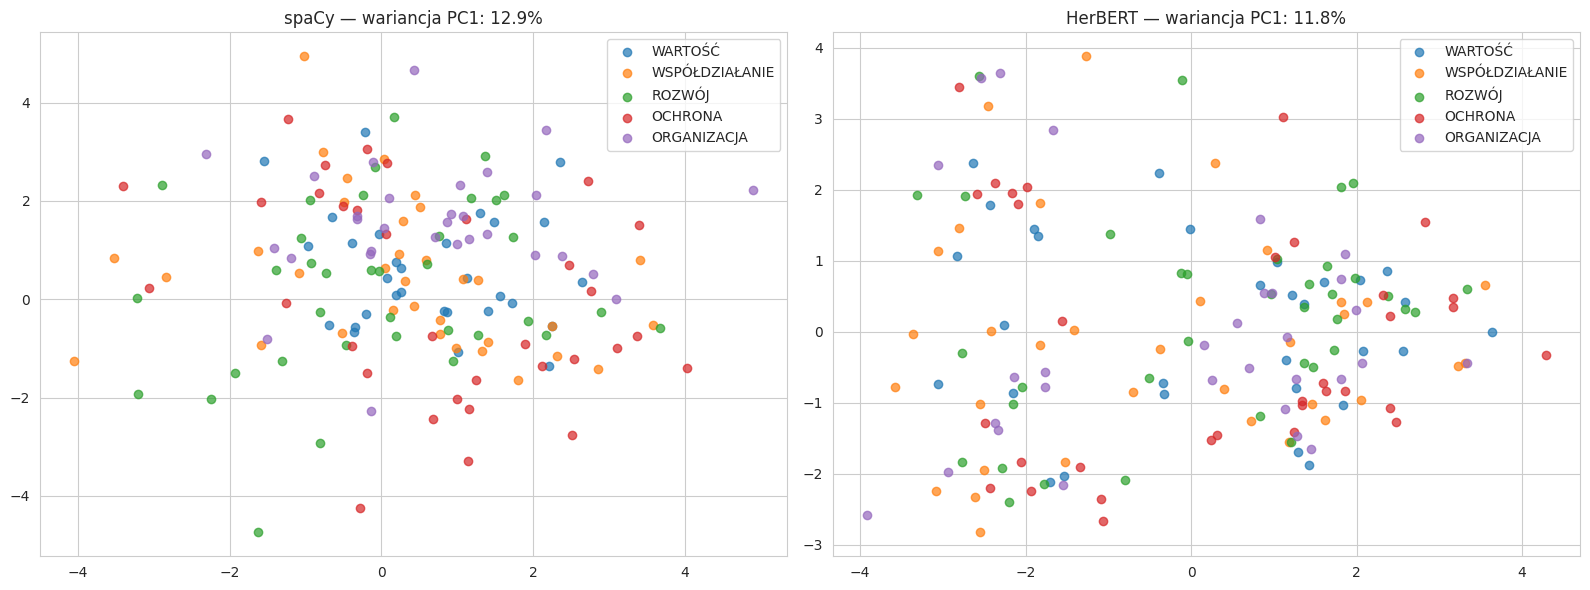

In [ ]:
pca_h = PCA(n_components=2)
coords_herbert = pca_h.fit_transform(wektory_herbert)

plot_df_h = pd.DataFrame(coords_herbert, columns=['PC1', 'PC2'])
plot_df_h['Kategoria'] = df_podobne['Ryk_label_'].values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# spaCy — tylko zbite kategorie
maska_spacy = plot_df['Kategoria'].isin(kategorie_podobne)
for kat in kategorie_podobne:
    m = plot_df['Kategoria'] == kat
    ax1.scatter(plot_df.loc[m, 'PC1'], plot_df.loc[m, 'PC2'], label=kat, alpha=0.7)
ax1.set_title(f"spaCy — wariancja PC1: {pca.explained_variance_ratio_[0]:.1%}")
ax1.legend()

# HerBERT
for kat in kategorie_podobne:
    m = plot_df_h['Kategoria'] == kat
    ax2.scatter(plot_df_h.loc[m, 'PC1'], plot_df_h.loc[m, 'PC2'], label=kat, alpha=0.7)
ax2.set_title(f"HerBERT — wariancja PC1: {pca_h.explained_variance_ratio_[0]:.1%}")
ax2.legend()

plt.tight_layout()
plt.show()

Poniżej wersja zawierająca naniesione centroidy w formie gwiazdek

/tmp/ipykernel_37403/2587640325.py:4: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



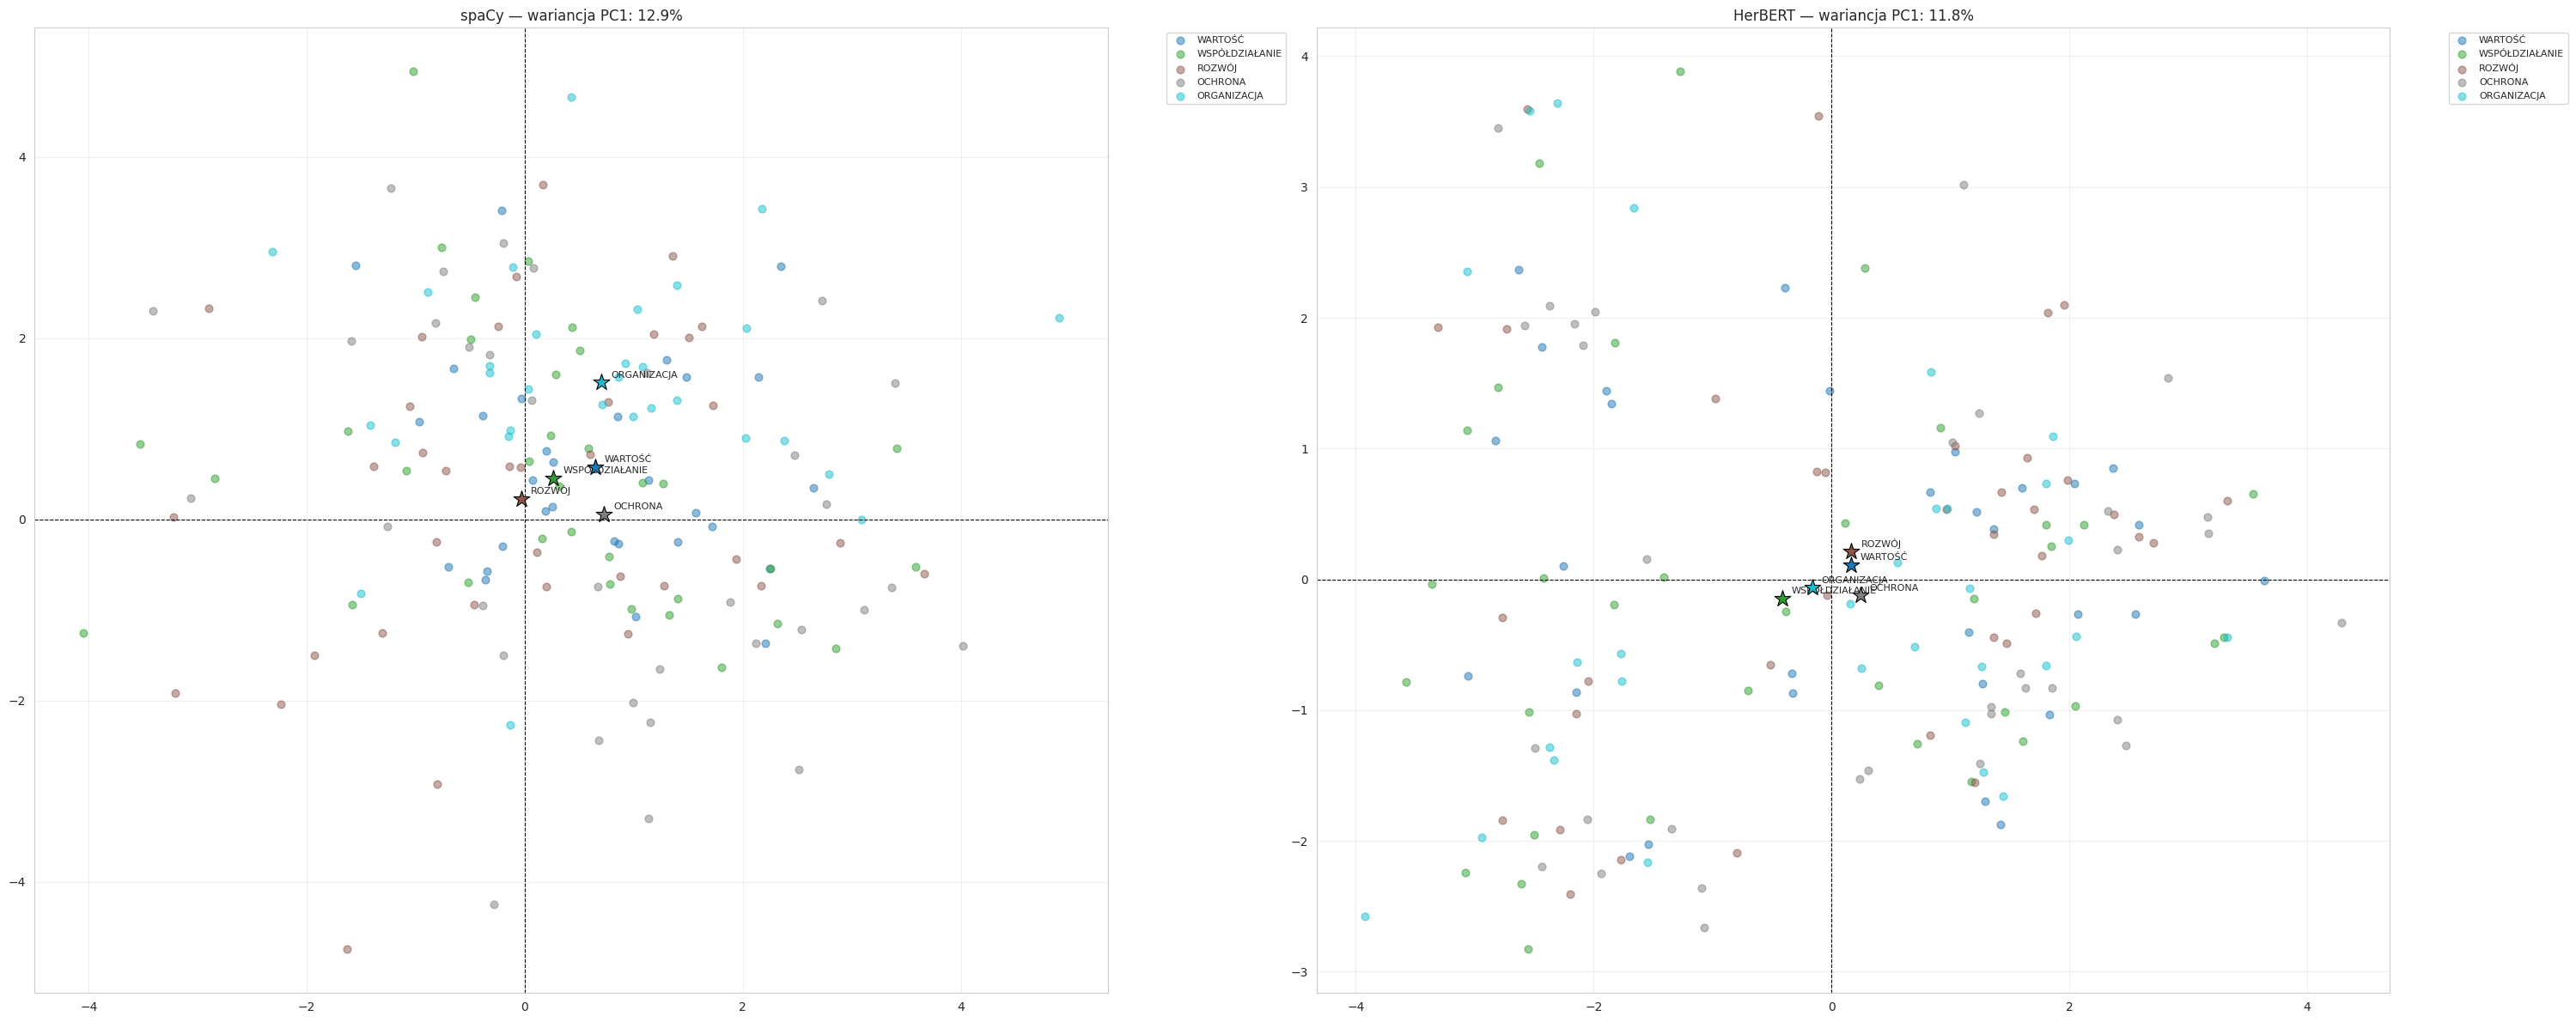

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 12))

kategorie_podobne = ['WARTOŚĆ', 'WSPÓŁDZIAŁANIE', 'ROZWÓJ', 'OCHRONA', 'ORGANIZACJA']
colors = plt.cm.get_cmap("tab10", len(kategorie_podobne))
kolor_mapy = {kat: colors(i) for i, kat in enumerate(kategorie_podobne)}

for ax, dane, tytul in [
    (ax1, plot_df[plot_df['Kategoria'].isin(kategorie_podobne)], f"spaCy — wariancja PC1: {pca.explained_variance_ratio_[0]:.1%}"),
    (ax2, plot_df_h, f"HerBERT — wariancja PC1: {pca_h.explained_variance_ratio_[0]:.1%}")
]:
    # Punkty
    for kat in kategorie_podobne:
        m = dane['Kategoria'] == kat
        ax.scatter(dane.loc[m, 'PC1'], dane.loc[m, 'PC2'],
                   color=kolor_mapy[kat], alpha=0.5, s=40, label=kat)

    # Centroidy
    centroidy = dane.groupby('Kategoria')[['PC1', 'PC2']].mean()
    for kat, row in centroidy.iterrows():
        ax.scatter(row['PC1'], row['PC2'],
                   color=kolor_mapy[kat], s=200, marker='*',
                   edgecolors='black', linewidth=0.8, zorder=5)
        ax.annotate(kat, (row['PC1'], row['PC2']),
                    textcoords="offset points", xytext=(8, 4), fontsize=8)

    ax.set_title(tytul)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

/tmp/ipykernel_37403/3994591335.py:4: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



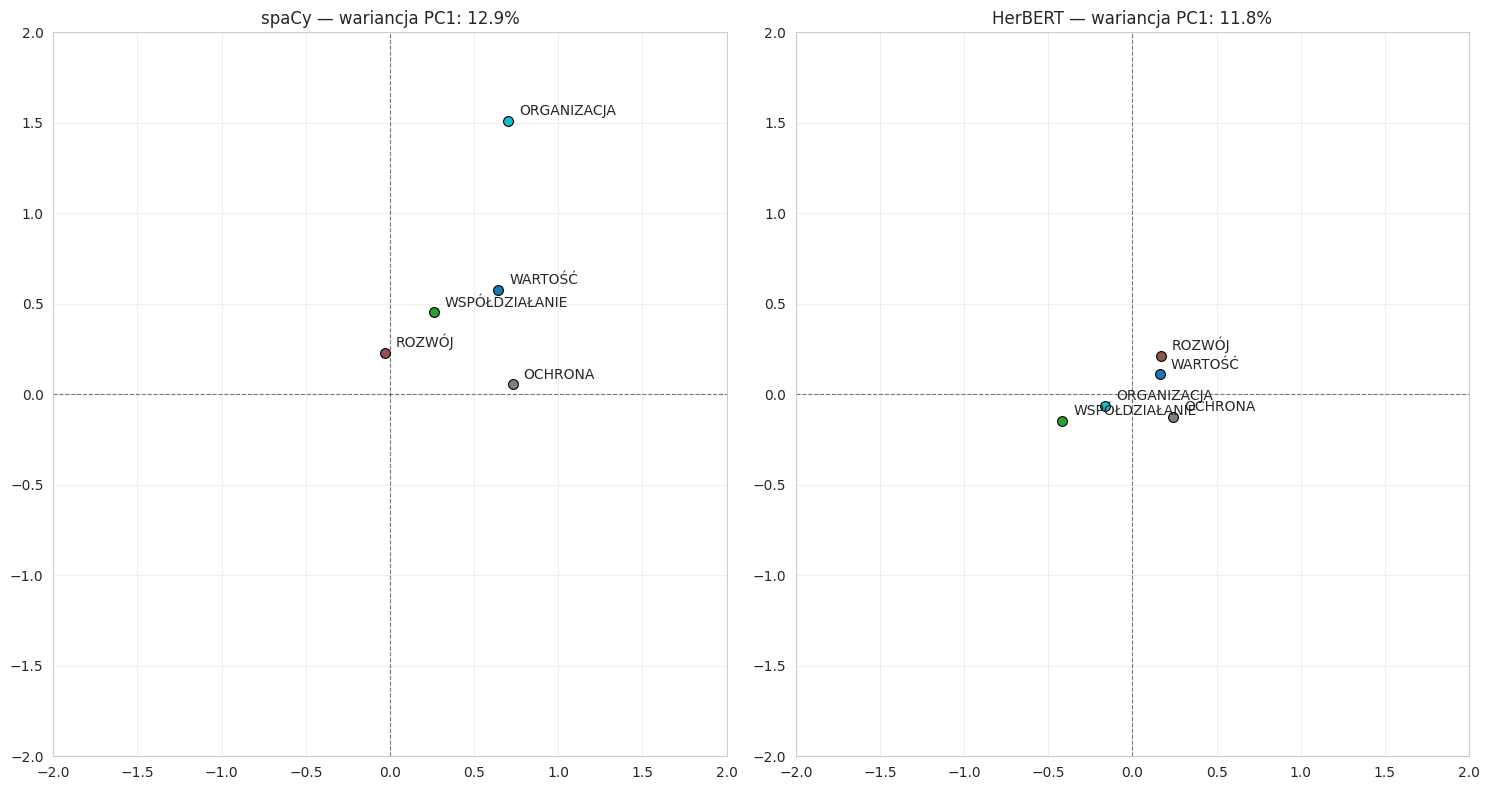

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

kategorie_podobne = ['WARTOŚĆ', 'WSPÓŁDZIAŁANIE', 'ROZWÓJ', 'OCHRONA', 'ORGANIZACJA']
colors = plt.cm.get_cmap("tab10", len(kategorie_podobne))
kolor_mapy = {kat: colors(i) for i, kat in enumerate(kategorie_podobne)}

for ax, dane, tytul in [
    (ax1, plot_df[plot_df['Kategoria'].isin(kategorie_podobne)], f"spaCy — wariancja PC1: {pca.explained_variance_ratio_[0]:.1%}"),
    (ax2, plot_df_h, f"HerBERT — wariancja PC1: {pca_h.explained_variance_ratio_[0]:.1%}")
]:


    # Centroidy
    centroidy = dane.groupby('Kategoria')[['PC1', 'PC2']].mean()
    for kat, row in centroidy.iterrows():
        ax.scatter(row['PC1'], row['PC2'],
                   color=kolor_mapy[kat], s=200, marker='.',
                   edgecolors='black', linewidth=0.8, zorder=5)
        ax.annotate(kat, (row['PC1'], row['PC2']),
                    textcoords="offset points", xytext=(8, 4), fontsize=10, zorder=6)

    ax.set_title(tytul, fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha = .5)
    ax.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha = .5)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

plt.tight_layout()

Z ciekawości - przeprowadźmy klasteryzację na embedingach herbert

In [ ]:
df_all = df.copy()

# Wektoryzacja
wektory_herbert = np.array([
    get_herbert_vector(tekst)
    for tekst in df_all['Rekomendacja']
])

print(f"Kształt macierzy: {wektory_herbert.shape}")
# → (n_rekomendacji, 768)  # HerBERT ma 768 wymiarów zamiast 300

Kształt macierzy: (298, 768)


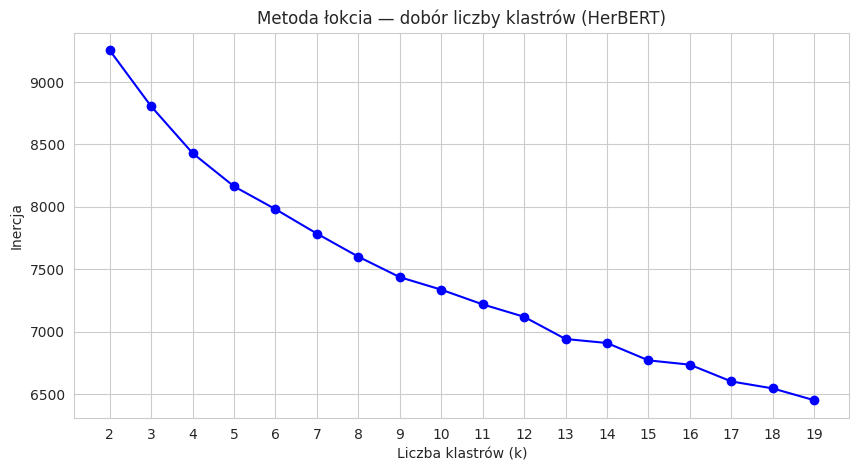

In [ ]:
inertia = []
K = range(2, 20)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(wektory_herbert)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K, inertia, "bo-")
plt.xlabel("Liczba klastrów (k)")
plt.ylabel("Inercja")
plt.title("Metoda łokcia — dobór liczby klastrów (HerBERT)")
plt.xticks(K)
plt.grid(True)

## Próba rozdzielenia rekomendacji do grup

Ogólna koncepca jest taka: Podobnie jak zwektoryzowaliśmy rekomendacje teraz zrobimy do samo z grupami roboczymi poprzez wektoryzację ich opisu w dokumencie MKiŚ

In [ ]:
df_grupy = pd.read_csv('/content/grupy_robocze_opisy.csv')
df_grupy.head()

,grupa_nr,grupa_nazwa,opis
0,1,Klimat adaptacja i łagodzenie zmian klimatu,dostosowanie lasów i leśnictwa do zmiany klima...
1,2,Ochrona ekosystemów leśnych i usługi ekosystemowe,usługi zaopatrujące regulacyjne kulturowe i ws...
2,3,Zrównoważone wykorzystanie drewna i ekonomika ...,zrównoważone pozyskanie drewna strategia podaż...
3,4,Zarządzanie lasami i organizacja leśnictwa,nadzór nad gospodarką leśną i lasami planowani...
4,5,Badania rozwój komunikacja i edukacja,współpraca z sektorem nauki transfer wiedzy i ...


Normalizacja i lematyzacja opisu grup roboczych

In [ ]:
def normalize_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^\w\s]", " ", text,
                  flags=re.UNICODE)
    text = re.sub(r"_", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

def lemmatize_and_remove_stopwords(text: str):
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_space
        and len(token.lemma_) > 2
        and token.lemma_ not in CUSTOM_STOPWORDS
    ]
    return " ".join(tokens)

def vectorize(text: str):
    doc = nlp(text)
    return doc.vector

In [ ]:
df_grupy['opis_mod'] = df_grupy.opis.apply(normalize_text)
df_grupy['lema'] = df_grupy.opis_mod.apply(lemmatize_and_remove_stopwords)

X_grupy = np.array([vectorize(text) for text in df_grupy['lema']])
X_grupy

array([[-0.37691733, -1.07633   ,  0.35513344, ...,  0.83230954,
         0.4875423 , -0.1037934 ],
       [ 1.0377785 , -1.8547298 , -0.45488468, ...,  0.690205  ,
         0.11738463,  0.03023465],
       [ 0.31709525, -1.1206058 , -0.27351707, ...,  0.86162066,
         1.0185735 , -0.22765653],
       [ 0.40641975, -1.9553574 , -0.1592591 , ...,  0.60465574,
         0.51458627, -0.25896332],
       [ 0.767635  , -2.06666   , -0.6362339 , ...,  0.3214869 ,
         0.12982671,  0.23502989]], dtype=float32)

In [ ]:
adam_embedings = X[adam.index,:]

In [ ]:
adam_labels = list(adam.label.astype(float).astype(int))
adam_labels = pd.Series(adam_labels)

Obliczamy centroidy w przestrzeni 300 wymiarowej na podstawie 140 rekomendacji ekspercko przydzielonych przez Adama do tylko jednej grupy roboczej

In [ ]:
centroidy = {}
for nr in range(1, 6):
    maska = adam_labels == nr
    centroidy[nr] = adam_embedings[maska].mean(axis=0)

In [ ]:
centroidy

{1: array([ 6.59480095e-01, -1.16185582e+00, -1.73642226e-02, -2.72122473e-01,
         3.74612957e-01, -2.96439856e-01,  4.69860196e-01,  4.56517816e-01,
        -1.76338151e-01, -3.12384576e-01, -2.65675575e-01,  7.99650848e-02,
        -1.61540985e+00, -4.78401065e-01, -4.21747297e-01, -5.03290474e-01,
        -3.56052481e-02,  2.96665579e-01, -6.16202176e-01, -5.19984424e-01,
        -1.27567098e-01, -3.90033245e-01,  1.60783246e-01, -6.40158892e-01,
        -1.14038384e+00,  5.69285929e-01, -1.66553676e-01, -3.59264851e-01,
        -1.51804239e-02, -1.00193417e+00, -3.46385241e-01, -5.26259184e-01,
        -9.38919306e-01,  2.50738412e-01,  1.17308110e-01,  3.71312536e-02,
        -1.34034777e+00, -5.21491349e-01,  8.46297085e-01, -3.30902308e-01,
        -6.49737120e-01,  7.56737649e-01, -1.26807773e+00,  6.01341426e-01,
        -1.92155206e+00,  8.72868061e-01, -4.11148757e-01,  4.50370908e-01,
        -1.85931718e-03, -1.27147838e-01, -1.12359989e+00, -5.94799995e-01,
         

In [ ]:
adam['id'] = adam.index
adam['label'] = adam.label.astype(float).astype(int)

In [ ]:
df['Nr rekomendacji'] = df['Nr rekomendacji'].astype(int)

In [ ]:
rekom = df[['Nr rekomendacji', 'Rekomendacja']].rename(columns = {'Rekomendacja':'tekst'})

In [ ]:
adam1 = adam[['label', 'id']].rename(columns = {'label':'grupa_robocza'})

In [ ]:
#Musimy dodać 1 bo gdzieś wcześniej wkradł się błąd w numeracji
adam1['id'] = adam1['id'] + 1

In [ ]:
klas_adama = rekom.merge(adam1, left_on='Nr rekomendacji', right_on = 'id', how='left')[['id','tekst', 'grupa_robocza']]
klas_adama

,id,tekst,grupa_robocza
0,1.0,W poszukiwaniu ogólnych/filozoficznych podstaw...,2.0
1,2.0,"Ekosystemy leśne prezentują wartości, spośród ...",2.0
2,3.0,Mamy do czynienia z pluralizmem antropologiczn...,2.0
3,NaN,Zarządzanie lasami powinno uwzględniać mnogość...,NaN
4,NaN,Ekosystem leśny/las nie jest jedynie przedmiot...,NaN
...,...,...,...
293,NaN,Zakłady doświadczalne trzech wydziałów leśnych...,NaN
294,NaN,Należy unormować status prawny trzech zakładów...,NaN
295,296.0,O rozwój badań leśnych upominała się „Polityka...,5.0
296,297.0,W celu podniesienia efektywności oraz poziomu ...,5.0


Poniżej mamy sposób przypisania rekomendacji do grup. Wybrano podejście hybrydowe tj. bazujemy zarówno na 140 rekomendacjach co do których ekspert nie miał wątpliwości że powinny trafić tylko do jednej grupy jaki i na opisie danej grupy tj. embedingach (wektorach) utworzonych z opisu grup roboczych w dokumencie MKiŚ

In [ ]:
KOLUMNA_ID    = "id"
KOLUMNA_TEKST = "tekst"
KOLUMNA_GRUPA = "grupa_robocza"               # NaN dla nieprzypisanych; wartości 1-5

PROG_WERYFIKACJI = 0.05   # jeśli delta top1-top2 < próg → flaga "wymaga_weryfikacji"

GRUPY = {
    1: "Klimat, adaptacja i łagodzenie zmian klimatu",
    2: "Ochrona ekosystemów leśnych i usługi ekosystemowe",
    3: "Zrównoważone wykorzystanie drewna i ekonomika leśnictwa",
    4: "Zarządzanie lasami i organizacja leśnictwa",
    5: "Badania, rozwój, komunikacja i edukacja",
}

In [ ]:
embeddings       = X
embeddingi_grup  = X_grupy
macierz_centroid = np.array([list(i) for i in centroidy.values()])
df = klas_adama

In [ ]:
assert len(embeddings) == len(df), "Liczba embeddingów != liczba rekomendacji"
print(f"  Rekomendacji: {len(df)}, wymiar: {embeddings.shape[1]}")

  Rekomendacji: 298, wymiar: 300


Mamy 2 grupy rekomendacji: 140 przypisanych ekspercko i 158 co do których są wątpliwości

In [ ]:
# Maski
maska_przypisanych    = df[KOLUMNA_GRUPA].notna()
maska_nieprzypisanych = ~maska_przypisanych
print(f"  Przypisanych: {maska_przypisanych.sum()}, nieprzypisanych: {maska_nieprzypisanych.sum()}")

  Przypisanych: 140, nieprzypisanych: 158


Obliczamy macierze podobieństwa:
- sim_opis - jak bardzo rekomendacja i jest podobna do opisu grupy j
- sim_centroid - jak bardzo rekomendacja i jest podobna do centroidu grupy j

In [ ]:
#macierze podobieństwa

sim_opis     = cosine_similarity(embeddings, embeddingi_grup)   # (300, 5)
sim_centroid = cosine_similarity(embeddings, macierz_centroid)  # (300, 5)


Obliczanie macierzy similarity...


Walidacja leave-one-out to serce całego modelu. Dla każdej z 140 przypisanych rekomendacji pytamy: gdybyśmy nie wiedzieli do której grupy należy, czy algorytm by to odgadł?
Dla każdej rekomendacji i:

1. Tymczasowo "wyjmujemy" ją z jej grupy
2. Przeliczamy centroid tej grupy bez niej (żeby nie ściągała)
3. Łączymy sygnał z opisu i centroidu: combined = w_opis × sim_opis + w_centroid × sim_centroid
4. Sprawdzamy czy grupa z najwyższym wynikiem zgadza się z prawdziwym przypisaniem

Robimy to dla 7 kombinacji wag — od "tylko opis grupy" tj. tylko zwektoryzowane opisy grup roboczych, przez różne proporcje po "tylko centroid" tj. ocena ekspercka — i mierzymy dokładność dla każdej z tych kombinacji. Najlepsza kombinacja idzie do finalnego przypisania

Wynik wskazuje, że najlepszy model to wersja hybrydowa z wagami opis MKIŚ=0.3, ocena ekspercka przez Adama=0.7 - uzyskana dokładność to 72% więc jest całkiem nieźle

In [ ]:
#walidacja LEAVE-ONE-OUT

print("\n── Walidacja leave-one-out na przypisanych rekomendacjach ──")

idx_przypisanych = np.where(maska_przypisanych)[0]
prawdziwe_grupy  = df.loc[maska_przypisanych, KOLUMNA_GRUPA].astype(int).values  # 1-5
n_grup           = {nr: (prawdziwe_grupy == nr).sum() for nr in range(1, 6)}

# Centroidy leave-one-out: dla każdej przypisanej rekomendacji i
# oblicz centroid jej grupy bez niej samej
def centroid_loo(i_local, grupa_nr, embeddings_przypisane, prawdziwe_grupy):
    """Centroid grupy bez i-tej rekomendacji (indeks lokalny wśród przypisanych)."""
    maska = (prawdziwe_grupy == grupa_nr)
    maska[i_local] = False
    n = maska.sum()
    if n == 0:
        return np.zeros(embeddings_przypisane.shape[1])
    return embeddings_przypisane[maska].mean(axis=0)

embeddings_przypisane = embeddings[idx_przypisanych]  # (140, 300d)

# Testuj różne kombinacje wag
warianty = [
    ("tylko_opis_grupy",  1.0, 0.0),
    ("tylko_centroid",    0.0, 1.0),
    ("hybrid_70_30",      0.7, 0.3),
    ("hybrid_60_40",      0.6, 0.4),
    ("hybrid_50_50",      0.5, 0.5),
    ("hybrid_40_60",      0.4, 0.6),
    ("hybrid_30_70",      0.3, 0.7),
]

wyniki_walidacji = []

for nazwa, w_opis, w_centroid in warianty:
    poprawne = 0

    for i_local, (i_global, grupa_nr) in enumerate(zip(idx_przypisanych, prawdziwe_grupy)):

        if w_centroid > 0:
            # Przelicz centroidy LOO dla tej rekomendacji
            centroidy_loo = np.vstack([
                centroid_loo(i_local, nr, embeddings_przypisane, prawdziwe_grupy)
                for nr in range(1, 6)
            ])
            sim_c = cosine_similarity(embeddings[i_global:i_global+1], centroidy_loo)[0]
        else:
            sim_c = np.zeros(5)

        sim_o = sim_opis[i_global]

        combined = w_opis * sim_o + w_centroid * sim_c
        przewidywana = combined.argmax() + 1  # 1-5

        if przewidywana == grupa_nr:
            poprawne += 1

    accuracy = poprawne / len(idx_przypisanych)
    wyniki_walidacji.append({"wariant": nazwa, "w_opis": w_opis, "w_centroid": w_centroid, "accuracy": accuracy})
    print(f"  {nazwa:25s}  accuracy = {accuracy:.1%}")

# Wybierz najlepszy wariant
best = max(wyniki_walidacji, key=lambda x: x["accuracy"])
print(f"\n  ✓ Najlepszy wariant: {best['wariant']}  (accuracy = {best['accuracy']:.1%})")
W_OPIS     = best["w_opis"]
W_CENTROID = best["w_centroid"]


── Walidacja leave-one-out na przypisanych rekomendacjach ──
  tylko_opis_grupy           accuracy = 59.3%
  tylko_centroid             accuracy = 71.4%
  hybrid_70_30               accuracy = 65.0%
  hybrid_60_40               accuracy = 67.1%
  hybrid_50_50               accuracy = 70.0%
  hybrid_40_60               accuracy = 71.4%
  hybrid_30_70               accuracy = 72.1%

  ✓ Najlepszy wariant: hybrid_30_70  (accuracy = 72.1%)


Używamy najlepszych wag do obliczenia combined_all dla wszystkich 298 rekomendacji. Dla każdej rekomendacji sortujemy 5 grup roboczych od najbardziej do najmniej pasującej i zapisujemy pełny ranking z wynikami.
Dodatkowo liczymy delta_top2 — różnicę między wynikiem grupy 1. i 2. w rankingu. Przyjąłem żę mała delta (poniżej progu 0.05) oznacza że dwie grupy są prawie równie dobre — te przypadki dostają flagę wymaga_weryfikacji = True.

In [ ]:
#finalne przypisanie

print(f"\n── Finalne przypisanie nieprzypisanych rekomendacji ──")
print(f"   Używam wag: opis={W_OPIS}, centroid={W_CENTROID}")

combined_all = W_OPIS * sim_opis + W_CENTROID * sim_centroid  # (300, 5)

wyniki = []
for i, row in df.iterrows():
    sim_row = combined_all[i]
    ranking = sorted(range(1, 6), key=lambda nr: sim_row[nr - 1], reverse=True)

    gr1, gr2  = ranking[0], ranking[1]
    delta     = sim_row[gr1 - 1] - sim_row[gr2 - 1]

    wyniki.append({
        KOLUMNA_ID:           row[KOLUMNA_ID],
        KOLUMNA_TEKST:        row.get(KOLUMNA_TEKST, ""),
        "grupa_dotychczasowa": row[KOLUMNA_GRUPA],
        "juz_przypisana":     pd.notna(row[KOLUMNA_GRUPA]),
        "rank_1_nr":          gr1,
        "rank_1_nazwa":       GRUPY[gr1],
        "rank_1_similarity":  round(float(sim_row[gr1 - 1]), 4),
        "rank_2_nr":          gr2,
        "rank_2_nazwa":       GRUPY[gr2],
        "rank_2_similarity":  round(float(sim_row[gr2 - 1]), 4),
        "rank_3_nr":          ranking[2],
        "rank_3_nazwa":       GRUPY[ranking[2]],
        "rank_3_similarity":  round(float(sim_row[ranking[2] - 1]), 4),
        "rank_4_nr":          ranking[3],
        "rank_4_nazwa":       GRUPY[ranking[3]],
        "rank_4_similarity":  round(float(sim_row[ranking[3] - 1]), 4),
        "rank_5_nr":          ranking[4],
        "rank_5_nazwa":       GRUPY[ranking[4]],
        "rank_5_similarity":  round(float(sim_row[ranking[4] - 1]), 4),
        "delta_top2":         round(float(delta), 4),
        "wymaga_weryfikacji": bool(delta < PROG_WERYFIKACJI),
    })

wyniki_df = pd.DataFrame(wyniki)


── Finalne przypisanie nieprzypisanych rekomendacji ──
   Używam wag: opis=0.3, centroid=0.7


Rozkład wygląda sensownie — dość równomierny, bez patologicznego skupienia w jednej grupie:

In [ ]:
#statystyki

nieprzys = wyniki_df[~wyniki_df["juz_przypisana"]]
print(f"\n  Rozkład przypisań (nieprzypisane, rank_1):")
print(nieprzys["rank_1_nazwa"].value_counts().to_string())
print(f"\n  Pewnie przypisane (delta ≥ {PROG_WERYFIKACJI}): {(~nieprzys['wymaga_weryfikacji']).sum()}")
print(f"  Wymagają weryfikacji:                          {nieprzys['wymaga_weryfikacji'].sum()}")


  Rozkład przypisań (nieprzypisane, rank_1):
rank_1_nazwa
Ochrona ekosystemów leśnych i usługi ekosystemowe          38
Zarządzanie lasami i organizacja leśnictwa                 37
Badania, rozwój, komunikacja i edukacja                    36
Zrównoważone wykorzystanie drewna i ekonomika leśnictwa    26
Klimat, adaptacja i łagodzenie zmian klimatu               21

  Pewnie przypisane (delta ≥ 0.05): 3
  Wymagają weryfikacji:                          155



── Confusion matrix (najlepszy wariant) ──

Classification report:
                precision    recall  f1-score   support

     1. Klimat       0.50      0.67      0.57        12
    2. Ochrona       0.65      0.68      0.67        41
  3. Ekonomika       0.69      0.85      0.76        13
4. Zarządzanie       0.81      0.68      0.74        37
    5. Badania       0.85      0.78      0.82        37

      accuracy                           0.72       140
     macro avg       0.70      0.73      0.71       140
  weighted avg       0.74      0.72      0.72       140



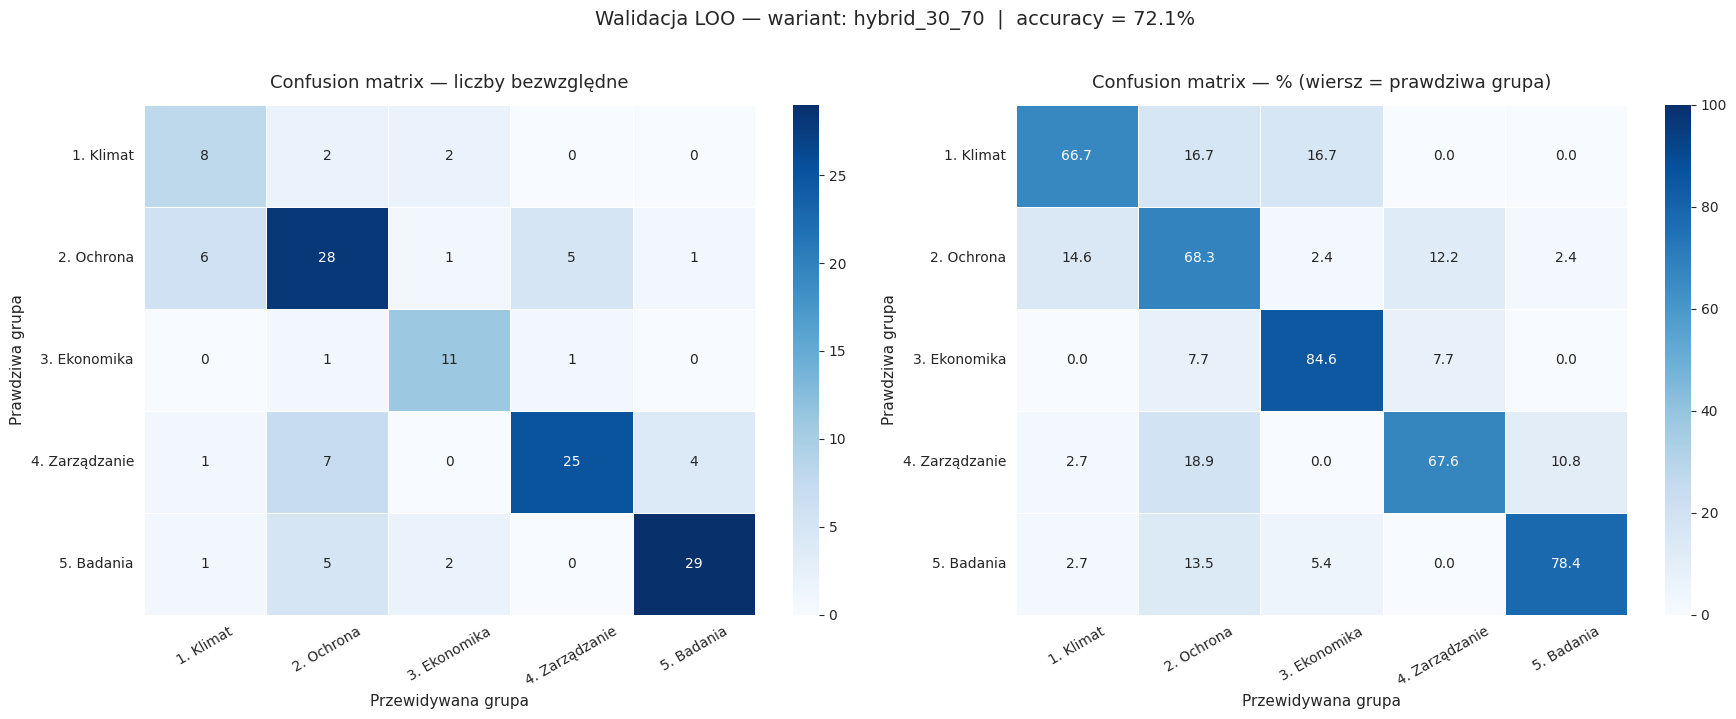

In [ ]:
przewidywane = []
for i_local, i_global in enumerate(idx_przypisanych):
    if W_CENTROID > 0:
        centroidy_loo = np.vstack([
            centroid_loo(i_local, nr, embeddings_przypisane, prawdziwe_grupy)
            for nr in range(1, 6)
        ])
        sim_c = cosine_similarity(embeddings[i_global:i_global+1], centroidy_loo)[0]
    else:
        sim_c = np.zeros(5)
    combined = W_OPIS * sim_opis[i_global] + W_CENTROID * sim_c
    przewidywane.append(combined.argmax() + 1)

przewidywane = np.array(przewidywane)

# Skrócone etykiety do wykresu
etykiety_skrot = [
    "1. Klimat",
    "2. Ochrona",
    "3. Ekonomika",
    "4. Zarządzanie",
    "5. Badania",
]


print("\nClassification report:")
print(classification_report(
    prawdziwe_grupy, przewidywane,
    labels=list(range(1, 6)),
    target_names=etykiety_skrot
))

# Macierz pomyłek — liczby bezwzględne
cm = confusion_matrix(prawdziwe_grupy, przewidywane, labels=list(range(1, 6)))

# Macierz pomyłek — procenty (względem prawdziwej klasy, wiersz = prawdziwa)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Lewy wykres — liczby
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=etykiety_skrot, yticklabels=etykiety_skrot,
    ax=axes[0], linewidths=0.5
)
axes[0].set_title("Confusion matrix — liczby bezwzględne", fontsize=13, pad=12)
axes[0].set_xlabel("Przewidywana grupa", fontsize=11)
axes[0].set_ylabel("Prawdziwa grupa", fontsize=11)
axes[0].tick_params(axis="x", rotation=30)
axes[0].tick_params(axis="y", rotation=0)

# Prawy wykres — procenty
sns.heatmap(
    cm_pct, annot=True, fmt=".1f", cmap="Blues",
    xticklabels=etykiety_skrot, yticklabels=etykiety_skrot,
    ax=axes[1], linewidths=0.5, vmin=0, vmax=100
)
axes[1].set_title("Confusion matrix — % (wiersz = prawdziwa grupa)", fontsize=13, pad=12)
axes[1].set_xlabel("Przewidywana grupa", fontsize=11)
axes[1].set_ylabel("Prawdziwa grupa", fontsize=11)
axes[1].tick_params(axis="x", rotation=30)
axes[1].tick_params(axis="y", rotation=0)

plt.suptitle(
    f"Walidacja LOO — wariant: {best['wariant']}  |  accuracy = {best['accuracy']:.1%}",
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

interpretacja:
Co działa dobrze:

Ekonomika (84.6%) — najbardziej wyrazista semantycznie, rzadko mylona z innymi
Badania (78.4%) i Ochrona (68.3%) — przyzwoita skuteczność
Zarządzanie (67.6%) — akceptowalne

Główne problemy:
- Ochrona → Klimat (14.6%) i Ochrona → Zarządzanie (12.2%)
To spodziewane — rekomendacje o ochronie ekosystemów często zahaczają o klimat (np. torfowiska, retencja wody) i o zarządzanie (np. lasy ochronne, parki narodowe).
- Zarządzanie → Ochrona (18.9%)
Duży wyciek — rekomendacje o zarządzaniu lasami często brzmią jak ochrona przyrody. To największy problem algorytmu.
- Badania → Ochrona (13.5%)
Rekomendacje o badaniach naukowych dotyczących przyrody są mylone z ochroną.
- Klimat — mała próba (12 rekomendacji)
66.7% accuracy przy n=12 to niepewny wynik — każdy błąd to 8.3%.

Praktyczny wniosek:
Granica Ochrona/Zarządzanie to największa szara strefa w Twoim zbiorze. Dla nieprzypisanych rekomendacji które algorytm przypisze do jednej z tych dwóch grup z małą deltą — warto zaplanować ręczną weryfikację ekspercką właśnie tam.

In [ ]:
#zapis

wyniki_df.to_excel("wyniki_przypisania.xlsx", index=False)

trudne = (
    nieprzys
    .sort_values("delta_top2")
    [[KOLUMNA_ID, KOLUMNA_TEKST,
      "rank_1_nr", "rank_1_nazwa", "rank_1_similarity",
      "rank_2_nr", "rank_2_nazwa", "rank_2_similarity",
      "delta_top2", "wymaga_weryfikacji"]]
)
trudne.to_excel("trudne_przypadki.xlsx", index=False)

pd.DataFrame(wyniki_walidacji).to_excel("walidacja_wagi.xlsx", index=False)

print("\nZapisano:")
print("  wyniki_przypisania.csv  — pełny ranking dla wszystkich 300 rekomendacji")
print("  trudne_przypadki.csv    — nieprzypisane posortowane od najtrudniejszych")
print("  walidacja_wagi.csv      — porównanie wariantów wag")


Zapisano:
  wyniki_przypisania.csv  — pełny ranking dla wszystkich 300 rekomendacji
  trudne_przypadki.csv    — nieprzypisane posortowane od najtrudniejszych
  walidacja_wagi.csv      — porównanie wariantów wag


Kolejne kierunki warte ewentualnej uwagi:

1. Analiza słów kluczowych per kategoria
Które słowa najsilniej charakteryzują każdą kategorię — TF-IDF pokaże co jest unikalne dla danej grupy, a nie tylko częste ogólnie.
pythonfrom sklearn.feature_extraction.text import TfidfVectorizer

2. Analiza podobieństwa między rekomendacjami
Macierz cosine similarity — które rekomendacje są do siebie najbardziej podobne niezależnie od kategorii. Może ujawnić że niektóre rekomendacje zostały przypisane do złej kategorii.

3. Analiza długości i złożoności rekomendacji
Czy kategorie różnią się długością, liczbą postulatów, złożonością zdań? Prosta analiza opisowa która może być interesująca merytorycznie.

4. Sieć współwystępowania słów
Graf pokazujący które terminy leśne pojawiają się razem — może ujawnić ukryte tematy przekrojowe między kategoriami.

5. Analiza czasowników — co rekomendacje postulują
Wyciągnięcie wszystkich czasowników (należy, powinno, wymaga, zaleca) i sprawdzenie czy kategorie różnią się siłą/typem postulatów.